In [1]:
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import imageio
import cv2
import dill
import numpy as np
import pandas as pd
from dataclasses import make_dataclass
import seaborn as sns
import os
from copy import deepcopy
from matplotlib.widgets import Slider

from four_room.env import FourRoomsEnv
from four_room.constants import train_config, size
from four_room.wrappers import gym_wrapper, gym_wrapper_state
from four_room.shortest_path import find_all_shortest_paths
from four_room.utils import obs_to_state

from utils.q_values import compute_mc

gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)

%load_ext autoreload
%autoreload 2

(<matplotlib.image.AxesImage at 0x242dfcbeb90>,
 array([list([(np.int64(13), np.int64(7), np.uint8(1)), (13, 7, 0), (13, 7, 3), (13, 6, 3), (13, 5, 3), (13, 4, 3), (13, 3, 3), (13, 3, 2), (12, 3, 2), (11, 3, 2), (10, 3, 2), (9, np.int64(3), 2), (8, np.int64(3), 2), (7, 3, 2), (6, 3, 2), (5, 3, 2), (4, 3, 2), (4, 3, 1), (4, 4, 1), (4, 5, 1), (4, 6, 1), (4, 7, 1), (np.int64(4), np.int64(8), 1)]),
        list([(np.int64(13), np.int64(7), np.uint8(1)), (13, 7, 2), (13, 7, 3), (13, 6, 3), (13, 5, 3), (13, 4, 3), (13, 3, 3), (13, 3, 2), (12, 3, 2), (11, 3, 2), (10, 3, 2), (9, np.int64(3), 2), (8, np.int64(3), 2), (7, 3, 2), (6, 3, 2), (5, 3, 2), (4, 3, 2), (4, 3, 1), (4, 4, 1), (4, 5, 1), (4, 6, 1), (4, 7, 1), (np.int64(4), np.int64(8), 1)]),
        list([(np.int64(13), np.int64(7), np.uint8(1)), (13, 7, 2), (12, 7, 2), (12, 7, 3), (12, 6, 3), (12, 5, 3), (12, 4, 3), (12, 3, 3), (12, 3, 2), (11, 3, 2), (10, 3, 2), (9, np.int64(3), 2), (8, np.int64(3), 2), (7, 3, 2), (6, 3, 2), (5, 3, 2), (

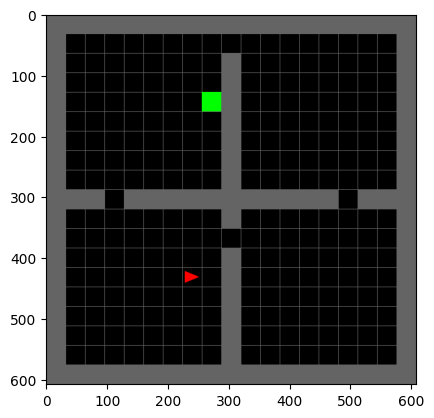

In [3]:
env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        

env.get_wrapper_attr('set_context')(199)
obs, _ = env.reset()
state = obs_to_state(obs)
paths = find_all_shortest_paths(state[:2], state[2], state[3:5], state[5:], size)


plt.imshow(cv2.transpose(env.render())), paths, env.get_wrapper_attr('context')

In [ ]:

def plot_map(file_name: str, env_ids: int):
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)

    for idx, ax in enumerate(axes.flat):
        matrix = results['heatmap'][env_ids[idx]]
        colors = np.full((19, 19), np.nan, dtype=float)

        colors[0, :] = 0
        colors[-1, :] = 0
        colors[:, 0] = 0
        colors[:, -1] = 0

        colors[9, :] = 0
        colors[:, 9] = 0
        
        env.get_wrapper_attr('set_context')(env_ids[idx])
        _, _ = env.reset()
        start_pos, doors_pos, goal_pos = env.get_wrapper_attr('context_info')(env_ids[idx])
        
        room_w = 19//2
        room_h = 19//2
        
        highlight_cells = []
        for j in range(0, 2):
            for i in range(0, 2):
                xL = i * room_w
                yT = j * room_h
                xR = xL + room_w
                yB = yT + room_h

                if i + 1 < 2:
                    pos = (xR, yT + 1 + doors_pos[j])
                    highlight_cells.append(pos)

                if j + 1 < 2:
                    pos = (xL + 1 + doors_pos[2 + i], yB)
                    highlight_cells.append(pos)
        
        colors[start_pos[0], start_pos[1]] = 1
        colors[goal_pos[0], goal_pos[1]] = 2

        for r, c in highlight_cells:
            colors[r, c] = np.nan

        matrix_data = deepcopy(matrix).astype(str)
        for r in range(matrix_data.shape[0]):
            for c in range(matrix_data.shape[1]):
                matrix_data[r, c] = str(int(matrix[r, c]))
                
        matrix_data[start_pos[0], start_pos[1]] = 'Start'
        matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'
        
        sns.heatmap(matrix, cmap='magma', annot=matrix_data, cbar_kws={'label': 'Number of switches'}, ax=ax, fmt='')

        overlay_cmap = sns.color_palette(["grey", "red", "lime"])
        sns.heatmap(colors, cmap=overlay_cmap, mask=np.isnan(colors), cbar=False, alpha=0.6, ax=ax)
        ax.set_title(f"H0eatmap Env {env_ids[idx]}")

    plt.tight_layout()
    plt.show()

    env.close()

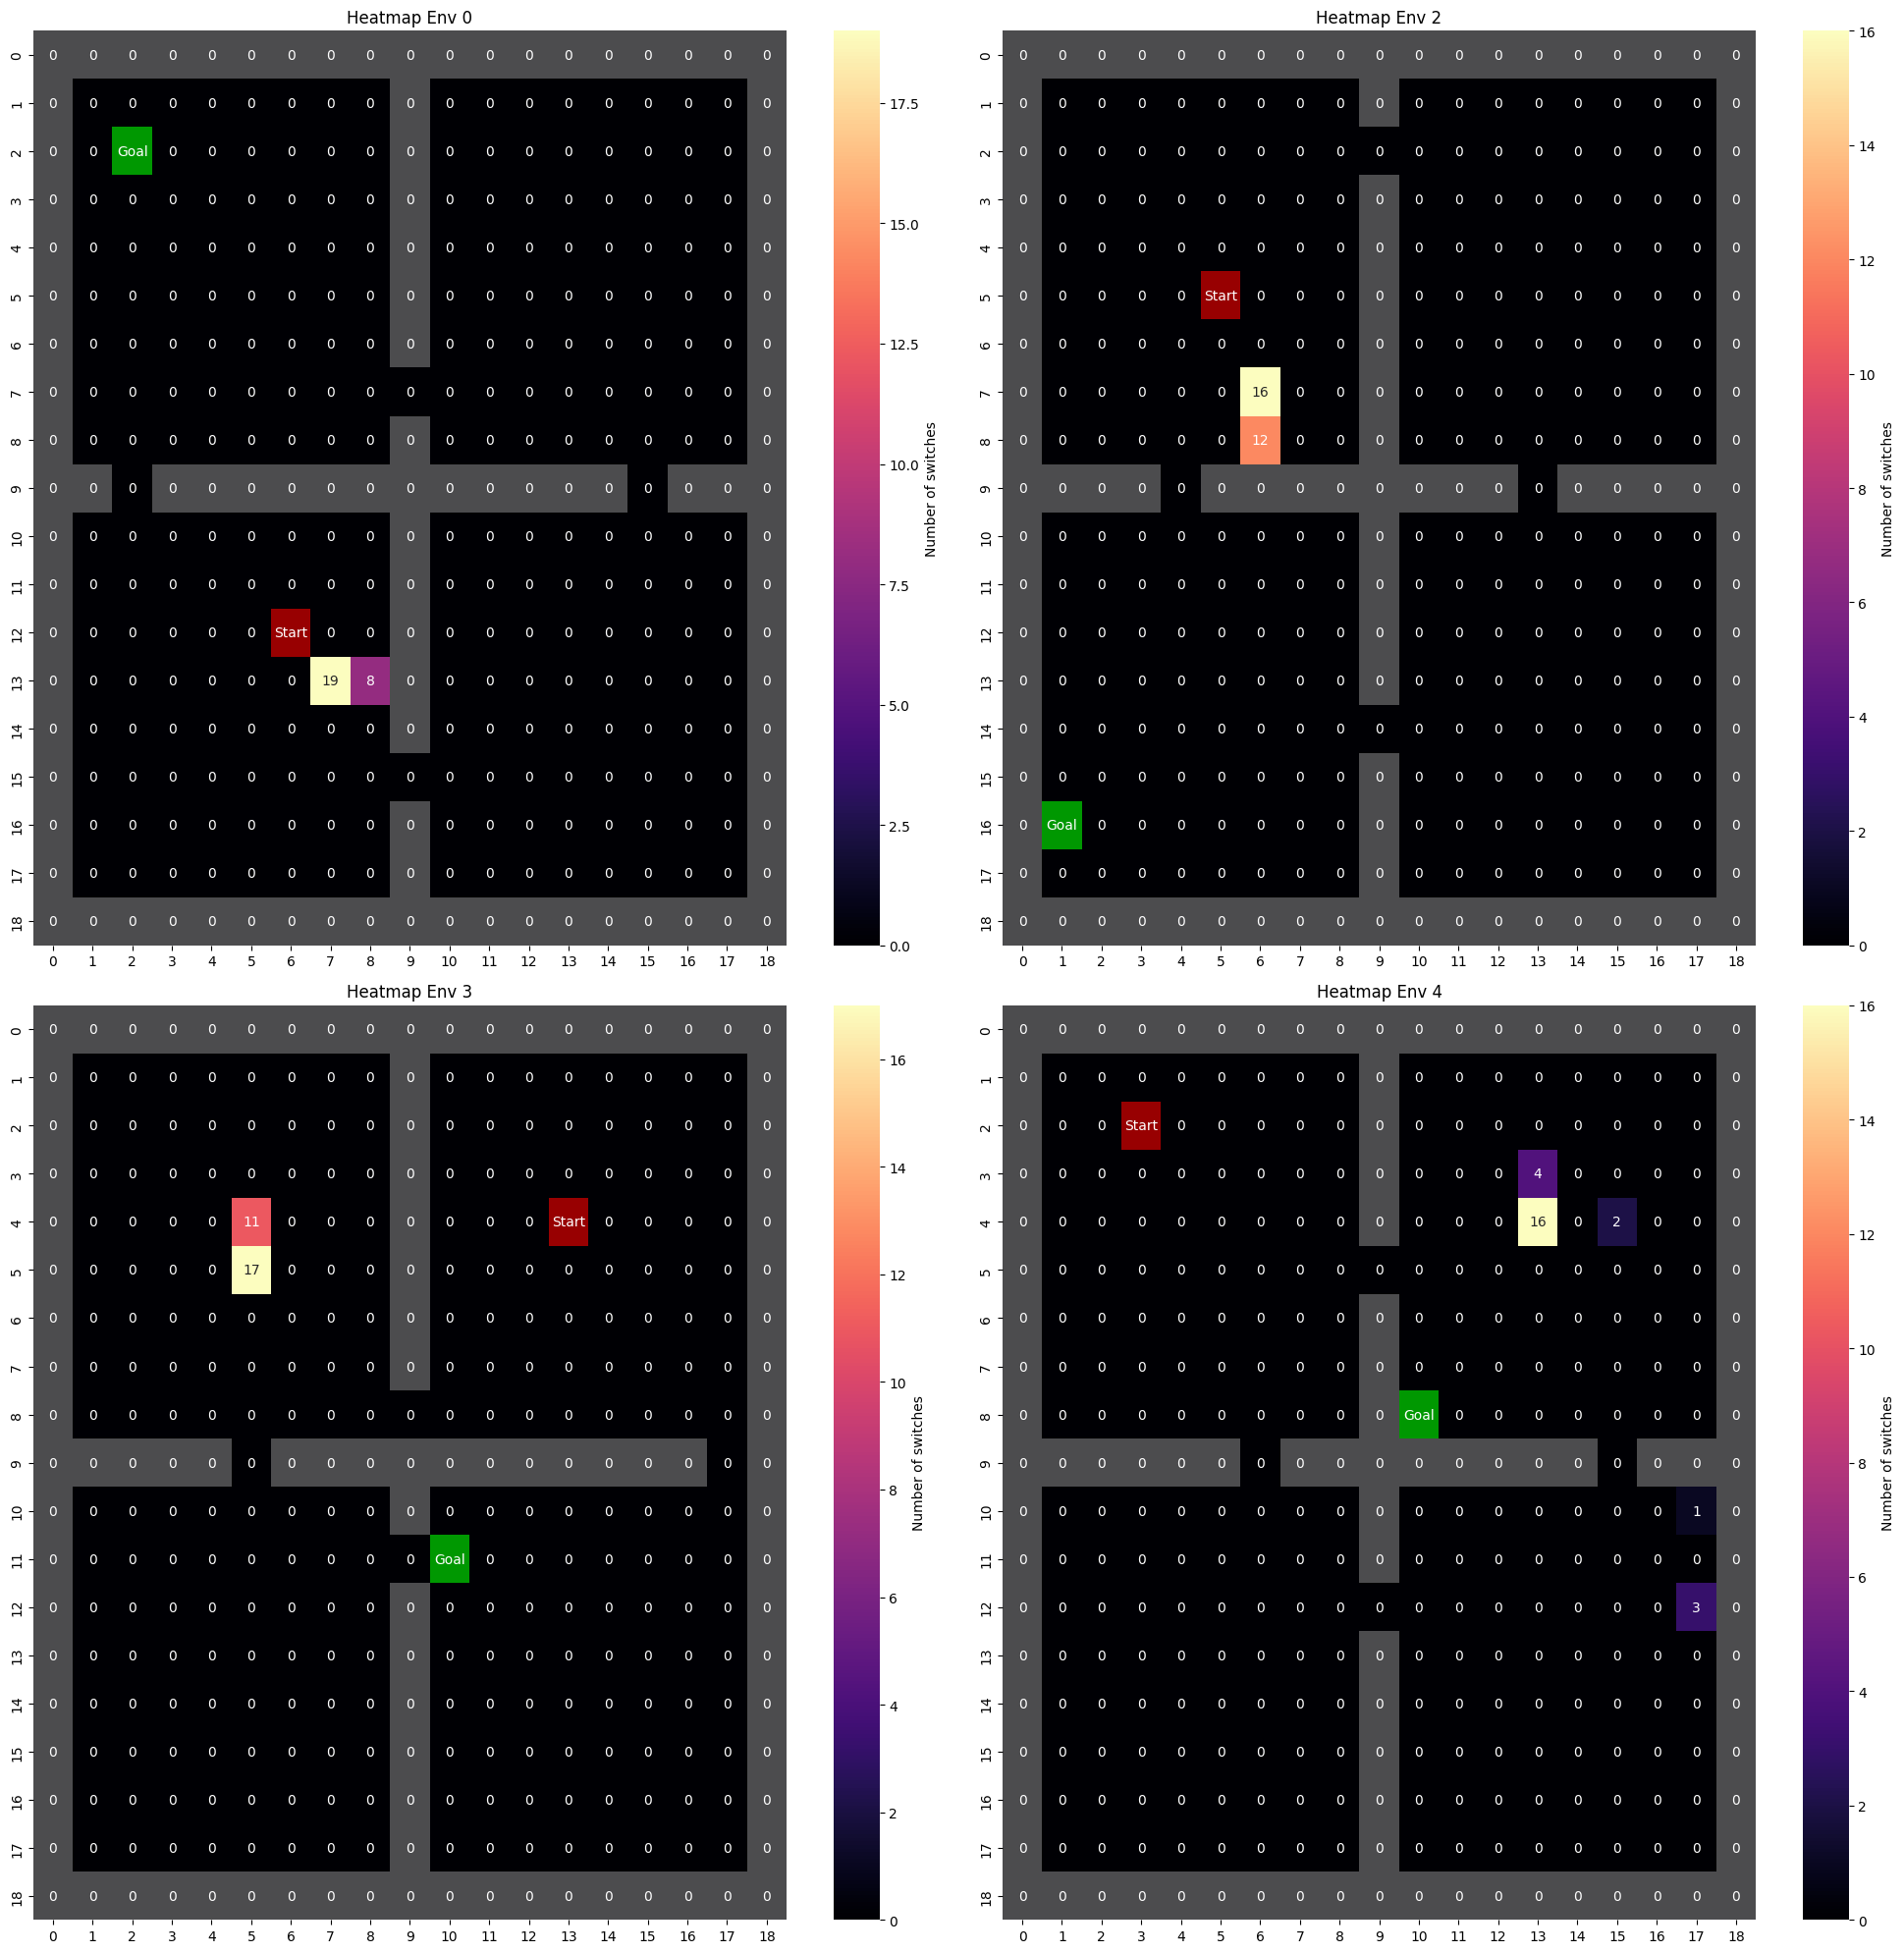

In [5]:
plot_map('basic_count_fixed_seed_0_100000', [0, 2, 3, 4])

In [3]:
def plot_env_heatmap(results, context_info: tuple, label: str, title: str, ax=None, annot: bool = True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    matrix = results
    colors = np.full((19, 19), np.nan, dtype=float)

    colors[0, :] = 0
    colors[-1, :] = 0
    colors[:, 0] = 0
    colors[:, -1] = 0
    colors[9, :] = 0
    colors[:, 9] = 0

    start_pos, doors_pos, goal_pos = context_info

    room_w = 19 // 2
    room_h = 19 // 2

    highlight_cells = []
    for j in range(2):
        for i in range(2):
            xL = i * room_w
            yT = j * room_h
            xR = xL + room_w
            yB = yT + room_h

            if i + 1 < 2:
                pos = (xR, yT + 1 + doors_pos[j])
                highlight_cells.append(pos)

            if j + 1 < 2:
                pos = (xL + 1 + doors_pos[2 + i], yB)
                highlight_cells.append(pos)

    colors[start_pos[0], start_pos[1]] = 1
    colors[goal_pos[0], goal_pos[1]] = 2

    for r, c in highlight_cells:
        colors[r, c] = np.nan

    matrix_data = deepcopy(matrix).astype(str)
    for r in range(matrix_data.shape[0]):
        for c in range(matrix_data.shape[1]):
            matrix_data[r, c] = str(int(matrix[r, c]))

    matrix_data[start_pos[0], start_pos[1]] = 'Start'
    matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'

    sns.heatmap(
        matrix,
        cmap='magma',
        annot=matrix_data if annot else False,
        cbar_kws={'label': label},
        ax=ax,
        xticklabels=False, 
        yticklabels=False,
        fmt=''
    )

    overlay_cmap = sns.color_palette(["grey", "red", "lime"])
    sns.heatmap(
        colors,
        cmap=overlay_cmap,
        mask=np.isnan(colors),
        cbar=False,
        alpha=0.6,
        xticklabels=False, 
        yticklabels=False,
        ax=ax
    )

    ax.set_title(f"{title}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    return ax

def find_states(history: list, timestep: int, capacity: int):
    states = []
    begin = timestep - capacity if timestep > capacity else 0
    
    for i in range(len(history)):
        step, context, x, y = history[i]    
        if begin <= step-1 <= timestep:
            states.append((context, x, y))
    
    return states

In [10]:
def plot_timestep(file_name: str, timestep: int, annot_expl: bool = True, remove_dir: bool = True):
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)
        
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )  
    
    # get switches
    switch_history = results['switch_states']
    buffer_switch_counts = np.zeros_like(results['heatmap'])
    buffer_moving = results['counter_moving']
    buffer_full = results['counter_full']
    full_switches = results['heatmap']
    explored_states = results['explore_heatmap']
    aux_states = results['aux_heatmap']
    
    relevant_switches = find_states(switch_history, timestep, buffer_moving.capacity)
    for switch in relevant_switches:
        buffer_switch_counts[*switch] += 1
    
    relevant_buffer_states = find_states(buffer_moving.all_states, timestep, buffer_moving.capacity)
    relevant_buffer = np.zeros_like(aux_states)
    for state in relevant_buffer_states:
        relevant_buffer[*state] += 1
        
    context = results['context_history'][timestep]
    context_info = env.get_wrapper_attr('context_info')(context)
    
    fig, axes = plt.subplots(3, 2, figsize=(20, 20))
    # moving switch count
    plot_env_heatmap(buffer_switch_counts[context], context_info,
                     'Switch Counts', f'Switches Heatmap for context {context}', axes[0, 0]) 
    # moving buffer count
    plot_env_heatmap(relevant_buffer[context], context_info, 
                     'Buffer Counts', f'Buffer Heatmap for context {context}', axes[0, 1]) 
    # full switches
    plot_env_heatmap(full_switches[context], context_info, 
                     'Switch Counts (full)', f'Switches Heatmap (full) for context {context}', axes[1, 0]) 
    # full buffer
    plot_env_heatmap(buffer_full.counts_matrix[context], context_info, 
                     'Buffer Counts (full)', f'Buffer Heatmap (full) for context {context}', axes[1, 1])
    # explored states 
    plot_env_heatmap(explored_states[context], context_info, 
                     'Explore Counts', f'Explored States (full) for context {context}', axes[2, 0], annot=annot_expl) 
    # aux selected states
    plot_env_heatmap(aux_states[context], context_info, 
                     'Aux Counts', f'Aux Selected Heatmap (full) for context {context}', axes[2, 1], annot=annot_expl)
    
    env.close()
    
    return (fig, axes)

In [174]:
env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )

In [176]:
print(env.get_wrapper_attr('context'))

0


0
0
((12, 6), (1, 5, 6, 5), (2, 2))


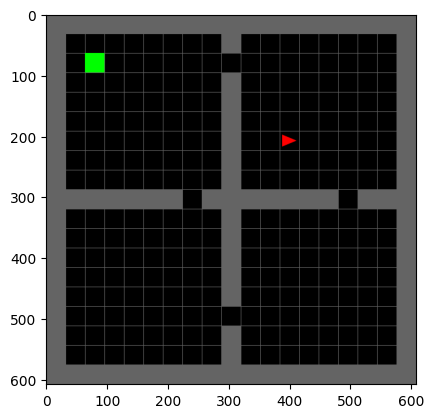

In [168]:
env.get_wrapper_attr('set_context')(0)
print(env.get_wrapper_attr('context'))
print(env.unwrapped.context)
print(env.get_wrapper_attr('context_info')(0))
env.reset()
plt.imshow(env.unwrapped.render());

In [10]:
with open(f'results/dqn_exps/dqn_count_test_seed_0_1000.pl', 'rb') as file:
    results = dill.load(file)

In [ ]:
import plotly.graph_objects as go

def plot_interactive_timesteps(file_name: str, timesteps: list[int], annot_expl: bool = True):
    figs_axes = [plot_timestep(file_name, t, annot_expl=annot_expl) for t in timesteps]
    figs = [f for f, _ in figs_axes]
    figs[0].canvas.draw_idle()
    
    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = Slider(ax_slider, 'Timestep', 0, len(figs) - 1, valinit=0, valstep=1)
    
    def update(val):
        idx = int(slider.val)
        figs[idx].canvas.draw_idle()
        
    slider.on_changed(update)
    plt.show()

In [ ]:
plot_interactive_timesteps('basic_count_fixed_moving_seed_0_100000', [10, 11, 12, 13])

Generating 4 matplotlib figures...
  Processing timestep 10 (1/4)
  Processing timestep 11 (2/4)
  Processing timestep 12 (3/4)
  Processing timestep 13 (4/4)
Done! Use the slider to navigate between timesteps.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rms(data_tuples, titles=None, figsize=(16, 5), style='ggplot',
             low_q=5, high_q=95, pad=0.1):
    plt.style.use(style)
    n = len(data_tuples)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for i, (means, stds) in enumerate(data_tuples):
        m = np.asarray(means, float)
        s = np.asarray(stds, float)
        x = np.arange(len(m))

        lower = m - s
        upper = m + s

        ax = axes[i]
        ax.plot(x, m)
        ax.fill_between(x, lower, upper, alpha=0.25)

        # robust y-limits: ignore extremes
        all_vals = np.concatenate([lower, upper])
        lo = np.nanpercentile(all_vals, low_q)
        hi = np.nanpercentile(all_vals, high_q)

        # add padding
        yr = hi - lo
        if yr == 0:
            yr = 1.0
        lo -= pad * yr
        hi += pad * yr
        ax.set_ylim(lo, hi)

        if titles:
            ax.set_title(titles[i])

        ax.grid(True)

    plt.tight_layout()
    return fig, axes


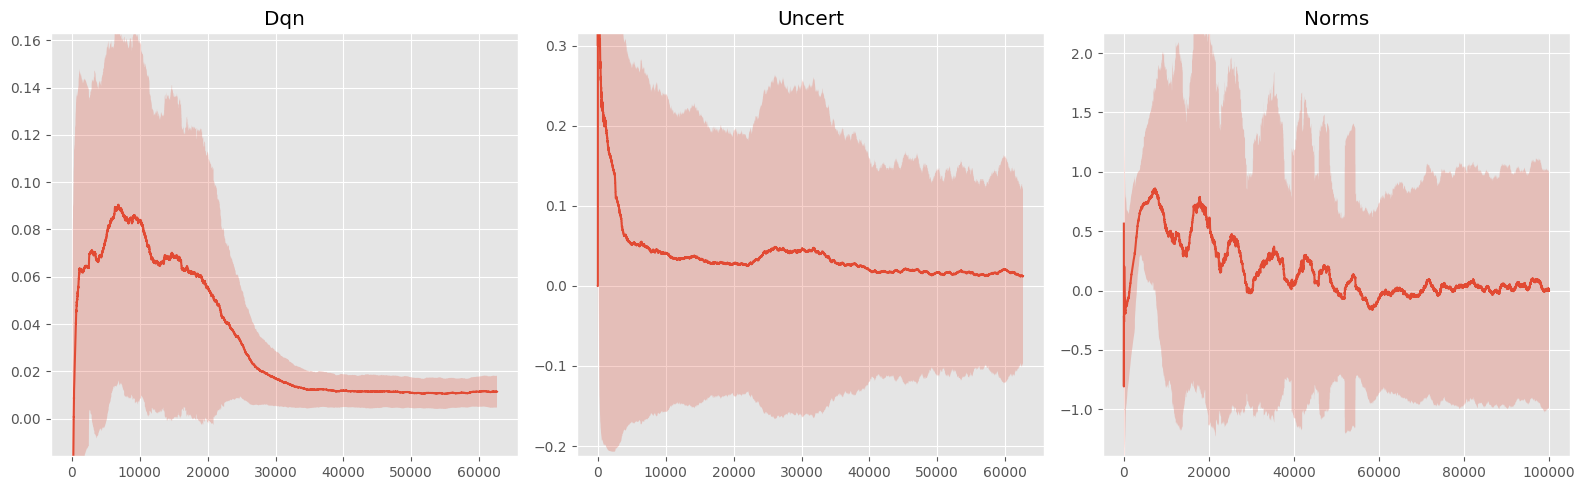

In [ ]:
with open(f'results/dqn_exps/dqn_count_test_seed_0_100000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

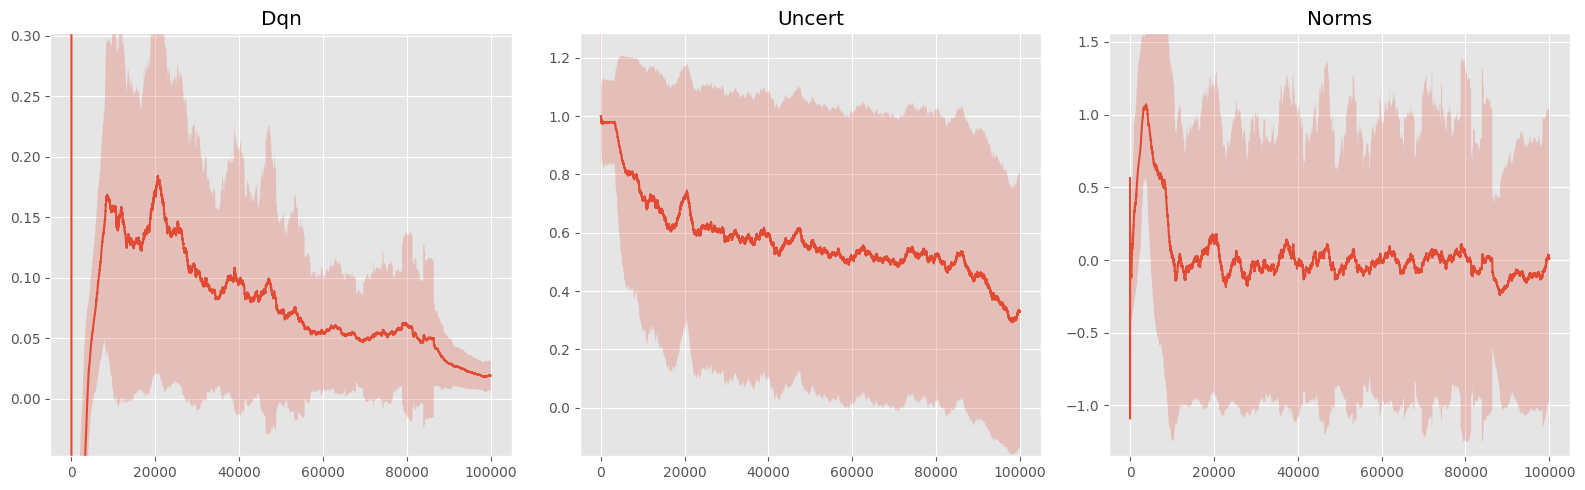

In [24]:
with open(f'results/dqn_exps/dqn_count_test_new_rms_seed_0_100000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

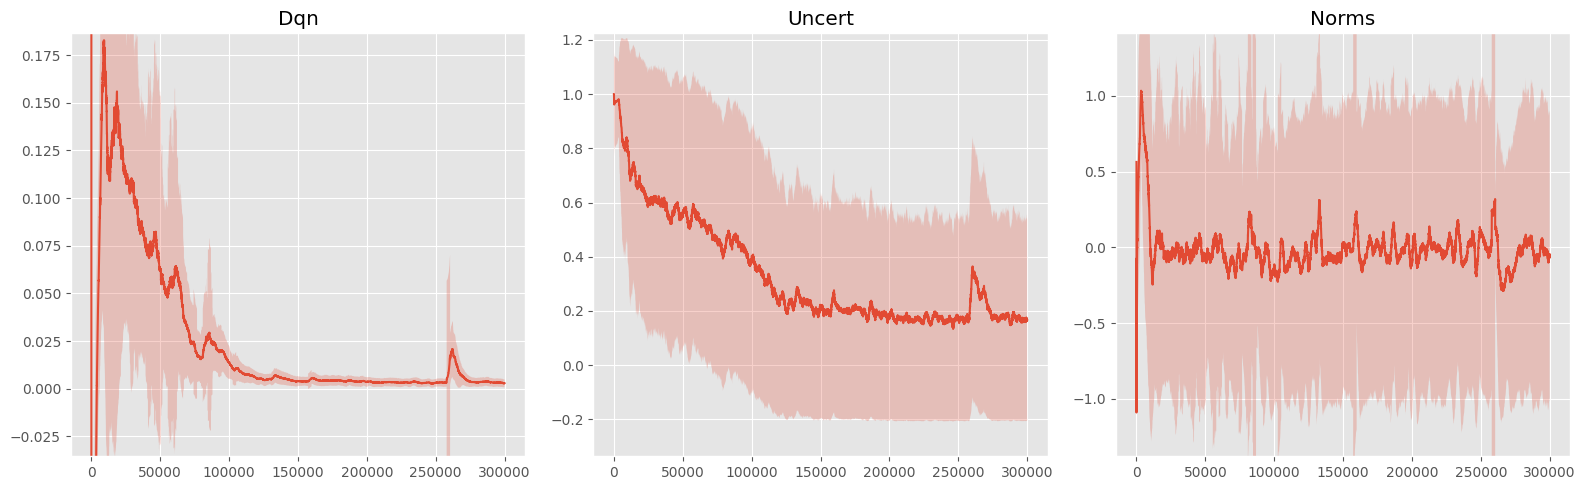

In [37]:
with open(f'results/dqn_exps/dqn_count_test_new_rms_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

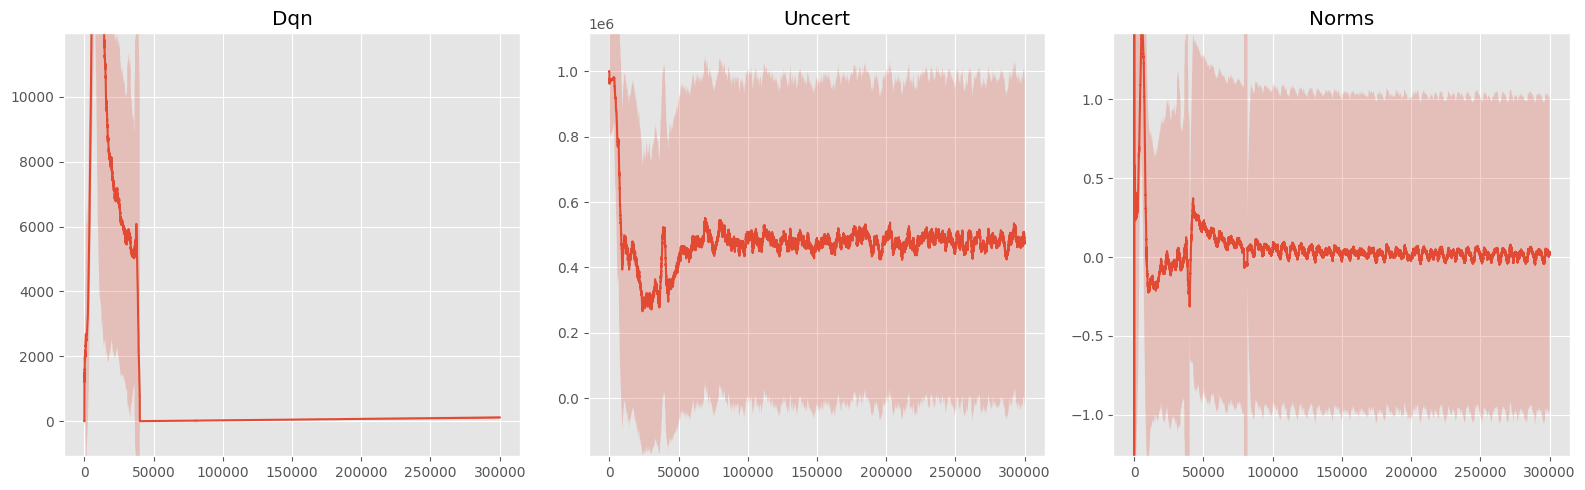

In [28]:
with open(f'results/dqn_exps/dqn_count_no_ones_new_rms_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

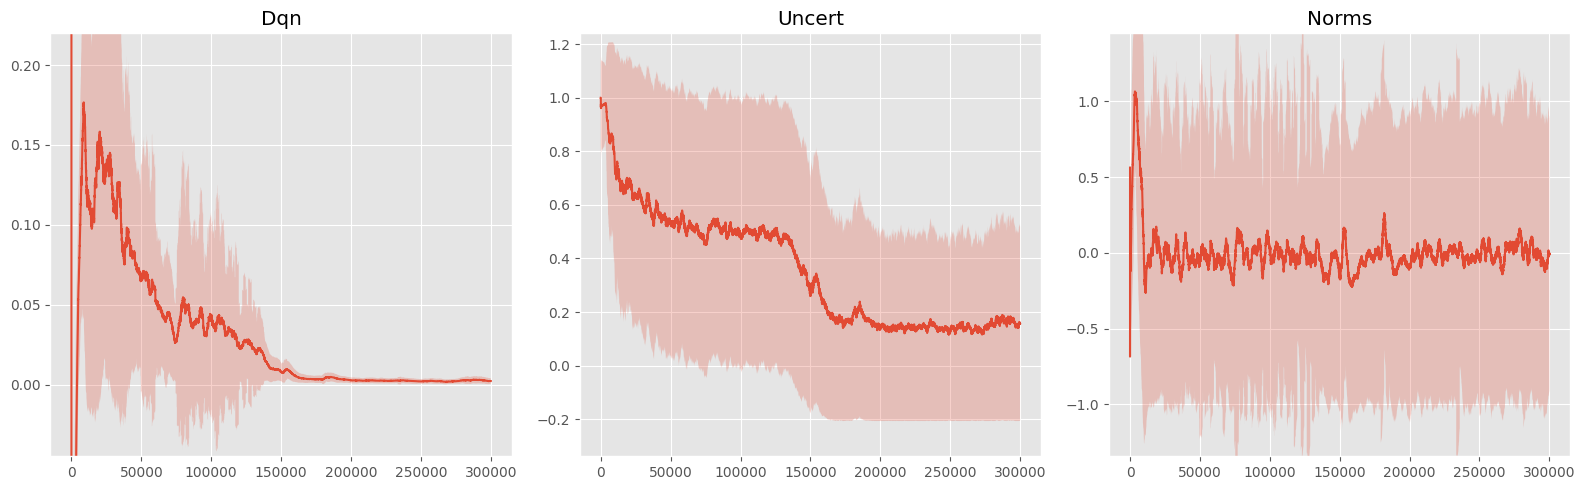

In [41]:
with open(f'results/dqn_exps/dqn_count_test_new_rms_low_lr_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

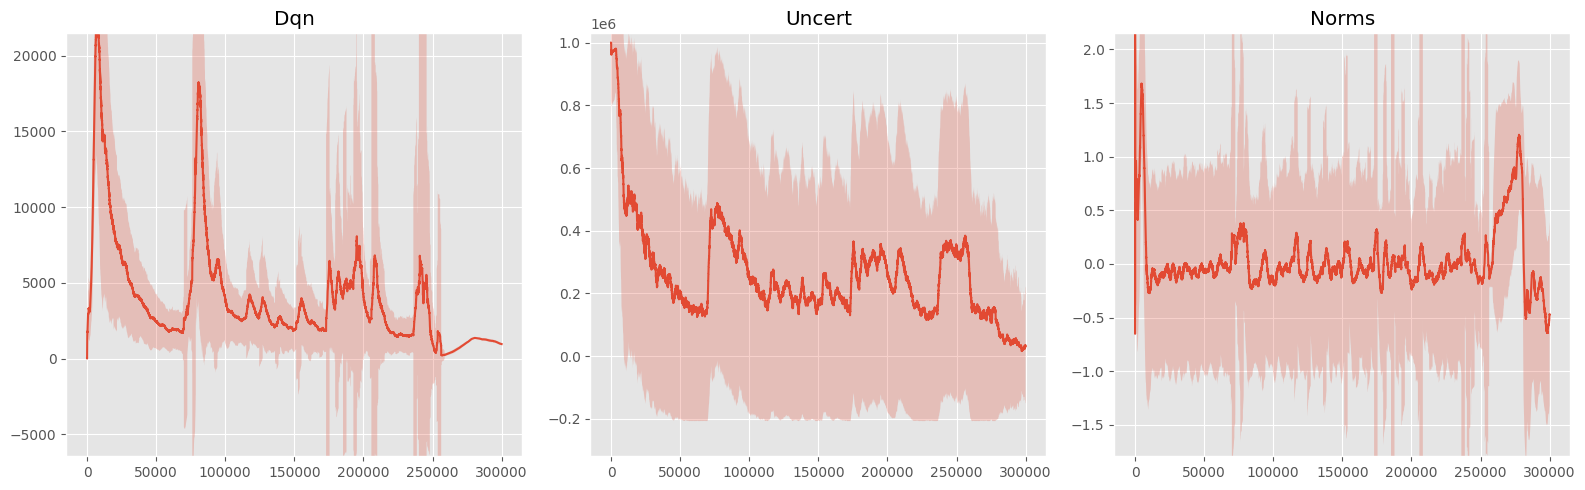

In [45]:
with open(f'results/dqn_exps/dqn_count_no_ones_new_rms_low_lr_seed_0_300000.pl', 'rb') as file:
    results = dill.load(file)

rms_dqn = results['running_mean']
rms_un = results['running_mean_un']
rms_norm = results['running_mean_norms']
plot_rms([(rms_dqn.means, rms_dqn.stds), (rms_un.means, rms_un.stds), (rms_norm.means, rms_norm.stds)], titles=['Dqn', 'Uncert', 'Norms']);

In [3]:
def make_table_opt(hyperparameters):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Ones", str),
        ("Alt", str),
        ("Window", int),
        ("Uniquness", float),
        ("Size", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for one in hyperparameters[1]:
            for alt in hyperparameters[2]:
                for window in hyperparameters[3]:
                    clean_alpha = str(alpha).replace(".", "")
                    file_name = f'opt_count_alpha{clean_alpha}_{one}_{alt}_window{window}_seed_0_300000.pl'
                    with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                        temp = dill.load(file)
                    
                    uniqueness = temp['uniqueness'][-1]
                    size = temp['counter_moving'].size

                    data_objs.append(
                        Config(alpha, one, alt, window, uniqueness, size, file_name)
                    ) 
            
    return pd.DataFrame(data_objs)

In [25]:
pd.set_option('display.max_colwidth', None)

make_table_opt(
    ([2.0, 3.0, 5.0], 
     ['none', 'return_ones'],
     ['none', 'alt'], 
     [500, 3500, 5000])
)

,Alpha,Ones,Alt,Window,Uniquness,Size,FileName
0,2.0,none,none,500,0.276410,100000,opt_count_alpha20_none_none_window500_seed_0_300000.pl
1,2.0,none,none,3500,0.276060,100000,opt_count_alpha20_none_none_window3500_seed_0_300000.pl
2,2.0,none,none,5000,0.275470,100000,opt_count_alpha20_none_none_window5000_seed_0_300000.pl
3,2.0,none,alt,500,0.081610,100000,opt_count_alpha20_none_alt_window500_seed_0_300000.pl
4,2.0,none,alt,3500,0.112262,74985,opt_count_alpha20_none_alt_window3500_seed_0_300000.pl
5,2.0,none,alt,5000,0.126601,67314,opt_count_alpha20_none_alt_window5000_seed_0_300000.pl
6,2.0,return_ones,none,500,0.276410,100000,opt_count_alpha20_return_ones_none_window500_seed_0_300000.pl
7,2.0,return_ones,none,3500,0.276060,100000,opt_count_alpha20_return_ones_none_window3500_seed_0_300000.pl
8,2.0,return_ones,none,5000,0.275470,100000,opt_count_alpha20_return_ones_none_window5000_seed_0_300000.pl
9,2.0,return_ones,alt,500,0.080500,100000,opt_count_alpha20_return_ones_alt_window500_seed_0_300000.pl


In [26]:
def make_table_count(hyperparameters):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Ones", str),
        ("LR", int),
        ("Uniqueness", float),
        ("Size", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for one in hyperparameters[1]:
            for lr in hyperparameters[2]:
                clean_alpha = str(alpha).replace(".", "")
                clean_lr = str(lr).replace(".", "")
                file_name = f'dqn_count_alpha{clean_alpha}_{one}_lr{clean_lr}_seed_0_300000.pl'
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                
                uniqueness = temp['uniqueness'][-1]
                size = temp['counter_moving'].size

                data_objs.append(
                    Config(alpha, one, lr, uniqueness, size, file_name)
                ) 
            
    return pd.DataFrame(data_objs)

In [27]:
make_table_count((
    [2.0, 3.0, 5.0], 
     ['none', 'return_ones'], 
     [0.01, 0.001, 0.0001, '0.00001']
))

,Alpha,Ones,LR,Uniqueness,Size,FileName
0,2.0,none,0.01,0.435442,23080,dqn_count_alpha20_none_lr001_seed_0_300000.pl
1,2.0,none,0.001,0.408917,22496,dqn_count_alpha20_none_lr0001_seed_0_300000.pl
2,2.0,none,0.0001,0.280322,43739,dqn_count_alpha20_none_lr00001_seed_0_300000.pl
3,2.0,none,0.00001,0.237826,59922,dqn_count_alpha20_none_lr000001_seed_0_300000.pl
4,2.0,return_ones,0.01,0.266736,52029,dqn_count_alpha20_return_ones_lr001_seed_0_300000.pl
5,2.0,return_ones,0.001,0.266191,52004,dqn_count_alpha20_return_ones_lr0001_seed_0_300000.pl
6,2.0,return_ones,0.0001,0.317388,38026,dqn_count_alpha20_return_ones_lr00001_seed_0_300000.pl
7,2.0,return_ones,0.00001,0.440923,36943,dqn_count_alpha20_return_ones_lr000001_seed_0_300000.pl
8,3.0,none,0.01,0.649940,10901,dqn_count_alpha30_none_lr001_seed_0_300000.pl
9,3.0,none,0.001,0.885060,4150,dqn_count_alpha30_none_lr0001_seed_0_300000.pl


In [4]:
def make_table_count(hyperparameters):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Epsilon", float),
        ("LastEpLen", int),
        ("Uniqueness", float),
        ("Size", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for eps in hyperparameters[1]:
            for lent in hyperparameters[2]:
                clean_alpha = str(alpha).replace(".", "")
                clean_eps = str(eps).replace(".", "")
                file_name = f'dqn_count_alpha{clean_alpha}_len{lent}_eps{clean_eps}_seed_0_300000.pl'
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                
                uniqueness = temp['uniqueness'][-1]
                size = temp['counter_moving'].size

                data_objs.append(
                    Config(alpha, eps, lent, uniqueness, size, file_name)
                ) 
            
    return pd.DataFrame(data_objs)

In [5]:
make_table_count((
    [1.5, 2.0, 2.5], 
     [0.05, 0.1], 
     [0, 20, 50, 100]
))

,Alpha,Epsilon,LastEpLen,Uniqueness,Size,FileName
0,1.5,0.05,0,0.22774,100000,dqn_count_alpha15_len0_eps005_seed_0_300000.pl
1,1.5,0.05,20,0.23542,100000,dqn_count_alpha15_len20_eps005_seed_0_300000.pl
2,1.5,0.05,50,0.22941,100000,dqn_count_alpha15_len50_eps005_seed_0_300000.pl
3,1.5,0.05,100,0.22690,100000,dqn_count_alpha15_len100_eps005_seed_0_300000.pl
4,1.5,0.10,0,0.20000,100000,dqn_count_alpha15_len0_eps01_seed_0_300000.pl
5,1.5,0.10,20,0.19174,100000,dqn_count_alpha15_len20_eps01_seed_0_300000.pl
6,1.5,0.10,50,0.20267,100000,dqn_count_alpha15_len50_eps01_seed_0_300000.pl
7,1.5,0.10,100,0.19883,100000,dqn_count_alpha15_len100_eps01_seed_0_300000.pl
8,2.0,0.05,0,0.30884,100000,dqn_count_alpha20_len0_eps005_seed_0_300000.pl
9,2.0,0.05,20,0.30791,100000,dqn_count_alpha20_len20_eps005_seed_0_300000.pl


In [5]:
def make_table_opt(hyperparameters):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Epsilon", float),
        ("Uniquness", float),
        ("Size", float),
        ("FileName", str),
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for eps in hyperparameters[1]:
            clean_alpha = str(alpha).replace(".", "")
            clean_eps = str(eps).replace(".", "")
            file_name = f'opt_count_alpha{clean_alpha}_eps{clean_eps}_seed_0_300000.pl'
            try:
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                uniqueness = temp['uniqueness'][-1]
                size = temp['counter_moving'].size
            except FileNotFoundError:
                uniqueness = np.nan
                size = np.nan

            data_objs.append(
                Config(alpha, eps, uniqueness, size, file_name)
            )
            
    return pd.DataFrame(data_objs)


In [9]:
make_table_opt((
    [1.5, 2.5, 3.5], 
     [0.05, 0.1, 0.15],
))

,Alpha,Epsilon,Uniquness,Size,FileName
0,1.5,0.05,0.25684,100000.0,opt_count_alpha15_eps005_seed_0_300000.pl
1,1.5,0.10,0.22101,100000.0,opt_count_alpha15_eps01_seed_0_300000.pl
2,1.5,0.15,0.18341,100000.0,opt_count_alpha15_eps015_seed_0_300000.pl
3,2.5,0.05,NaN,NaN,opt_count_alpha25_eps005_seed_0_300000.pl
4,2.5,0.10,0.25765,100000.0,opt_count_alpha25_eps01_seed_0_300000.pl
5,2.5,0.15,0.20918,100000.0,opt_count_alpha25_eps015_seed_0_300000.pl
6,3.5,0.05,NaN,NaN,opt_count_alpha35_eps005_seed_0_300000.pl
7,3.5,0.10,0.31210,100000.0,opt_count_alpha35_eps01_seed_0_300000.pl
8,3.5,0.15,0.23396,100000.0,opt_count_alpha35_eps015_seed_0_300000.pl


In [6]:
make_table_opt((
    [1.5, 2.5, 3.5], 
     [0.05, 0.1, 0.15],
))

,Alpha,Epsilon,Uniquness,Size,FileName
0,1.5,0.05,0.25958,100000.0,opt_count_alpha15_eps005_seed_0_300000.pl
1,1.5,0.10,0.22070,100000.0,opt_count_alpha15_eps01_seed_0_300000.pl
2,1.5,0.15,0.18275,100000.0,opt_count_alpha15_eps015_seed_0_300000.pl
3,2.5,0.05,NaN,NaN,opt_count_alpha25_eps005_seed_0_300000.pl
4,2.5,0.10,0.25923,100000.0,opt_count_alpha25_eps01_seed_0_300000.pl
5,2.5,0.15,0.21001,100000.0,opt_count_alpha25_eps015_seed_0_300000.pl
6,3.5,0.05,NaN,NaN,opt_count_alpha35_eps005_seed_0_300000.pl
7,3.5,0.10,0.29556,100000.0,opt_count_alpha35_eps01_seed_0_300000.pl
8,3.5,0.15,0.23990,100000.0,opt_count_alpha35_eps015_seed_0_300000.pl


In [15]:
def make_table_combined(hyperparameters):
    Config = make_dataclass("Config", [
        ("Epsilon", float),
        ("Uniqueness", float),
        ("Size", int),
        ("Score", float),
        ("FileName", str),
    ])
    
    data_objs = []
    for eps in hyperparameters[0]:
        seed_comb = []
        for seed in [0, 1, 2]:
            clean_eps = str(eps).replace(".", "")
            file_name = f'comb_eps_mode{clean_eps}_seed_{seed}_400000.pl'
            try:
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                    seed_comb.append(temp)
            except FileNotFoundError:
                continue

        uniqueness = np.mean([temp['uniqueness'][-1] for temp in seed_comb])
        size = np.mean([temp['counter_moving'].size for temp in seed_comb])
        reg_scores = [temp['reg_test_scores'] for temp in seed_comb]
        
        it = 0
        total = 0
        for scores in reg_scores:
            if len(scores) == 0:
                continue
            else:
                total += np.mean(scores)
                it += 1
                
        score = total / it if it != 0 else 0       

        data_objs.append(
            Config(eps, uniqueness, size, score, file_name)
        ) 
            
    return pd.DataFrame(data_objs)

In [ ]:
make_table_combined(([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 1.0],)) # alpha 2.0

,Epsilon,Uniqueness,Size,Score,FileName
0,0.00,0.320974,46823.333333,0.000000,comb_eps_mode0_seed_2_400000.pl
1,0.05,0.350342,45666.333333,0.000000,comb_eps_mode005_seed_2_400000.pl
2,0.10,0.344692,53424.333333,0.000000,comb_eps_mode01_seed_2_400000.pl
3,0.15,0.341390,59670.666667,0.000000,comb_eps_mode015_seed_2_400000.pl
4,0.20,0.327155,68017.666667,0.000000,comb_eps_mode02_seed_2_400000.pl
5,0.25,0.309117,81063.333333,0.000000,comb_eps_mode025_seed_2_400000.pl
6,0.30,0.297790,93954.666667,0.000000,comb_eps_mode03_seed_2_400000.pl
7,0.35,0.296013,100000.000000,0.698333,comb_eps_mode035_seed_2_400000.pl
8,0.40,0.314773,100000.000000,0.670000,comb_eps_mode04_seed_2_400000.pl
9,0.45,0.339337,100000.000000,0.700000,comb_eps_mode045_seed_2_400000.pl


In [ ]:
def make_table_combined_2(hyperparameters):
    Config = make_dataclass("Config", [
        ("Epsilon", float),
        ("Uniqueness", float),
        ("Size", int),
        ("Score", float),
        ("UB", float),
        ("LB", float),
        ("Num_Runs", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for eps in hyperparameters[0]:
        seed_comb = []
        for seed in [0, 1, 2]:
            clean_eps = str(eps).replace(".", "")
            file_name = f'comb_eps_mode{clean_eps}_seed_{seed}_500000.pl'
            try:
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                    seed_comb.append(temp)
            except FileNotFoundError:
                continue

        uniqueness = np.mean([temp['uniqueness'][-1] for temp in seed_comb])
        size = np.mean([temp['counter_moving'].size for temp in seed_comb])
        reg_scores = [temp['reg_test_scores'] for temp in seed_comb]
        
        it = 0
        total = 0
        num = 0 
        means = []
        for scores in reg_scores:
            if len(scores) == 0:
                continue
            else:
                total += np.mean(scores)
                means.append(np.mean(scores))
                it += 1    
            num += len(scores)
            
        score = total / it if it != 0 else 0  
        ub = np.percentile(means, q=95) 
        lb = np.percentile(means, q=5)    

        data_objs.append(
            Config(eps, uniqueness, size, score, ub, lb, num, file_name)
        ) 
            
    return pd.DataFrame(data_objs)

In [ ]:
make_table_combined_2(([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],), 165) # [50, 50]

,Epsilon,Uniqueness,Size,Score,Num_Runs,FileName
0,0.00,0.268043,100000.0,0.604167,6,comb_eps_mode0_alpha165_seed_2_400000.pl
1,0.05,0.286477,100000.0,0.647500,6,comb_eps_mode005_alpha165_seed_2_400000.pl
2,0.10,0.301727,100000.0,0.640000,6,comb_eps_mode01_alpha165_seed_2_400000.pl
3,0.15,0.318827,100000.0,0.687500,6,comb_eps_mode015_alpha165_seed_2_400000.pl
4,0.20,0.332810,100000.0,0.696667,6,comb_eps_mode02_alpha165_seed_2_400000.pl
5,0.25,0.347767,100000.0,0.680000,6,comb_eps_mode025_alpha165_seed_2_400000.pl
6,0.30,0.358190,100000.0,0.706667,6,comb_eps_mode03_alpha165_seed_2_400000.pl
7,0.40,0.374770,100000.0,0.708056,7,comb_eps_mode04_alpha165_seed_2_400000.pl
8,0.50,0.370337,100000.0,0.711111,9,comb_eps_mode05_alpha165_seed_2_400000.pl
9,0.60,0.316760,100000.0,0.715556,9,comb_eps_mode06_alpha165_seed_2_400000.pl


In [2]:
def make_table_comb(hyperparameters):
    Config = make_dataclass("Config", [
        ("BS", int),
        ("Tau", float),
        ("LR", float),
        ("Steps", int),
        ("Uniqueness", float),
        ("Size", float),
        ("FileName", str),
    ])
    
    data_objs = []
    for bs in hyperparameters[0]:
        for lr in hyperparameters[1]:
            for tau in hyperparameters[2]:
                for step in hyperparameters[3]:
                    clean_tau = str(tau).replace(".", "")
                    clean_lr = str(lr).replace(".", "")
                    file_name = f'comb_lr{clean_lr}_tau{clean_tau}_steps{step}_bs{bs}_alpha16_seed_0_300000.pl'
                    try:
                        with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                            temp = dill.load(file)
                        uniqueness = temp['uniqueness'][-1]
                        size = temp['counter_moving'].size
                    except FileNotFoundError:
                        uniqueness = np.nan
                        size = np.nan

                    data_objs.append(
                        Config(bs, tau, lr, step, uniqueness, size, file_name)
                    )
            
    return pd.DataFrame(data_objs)


In [8]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = make_table_comb((
    [64, 128, 256], 
    [0.001, 0.0001],
    [0.01, 0.1, 0.5, 1.0], 
    [5, 10, 15]
))

df.sort_values(by='Uniqueness', ascending=False)

,BS,Tau,LR,Steps,Uniqueness,Size,FileName
16,64,0.10,0.0001,10,0.364540,100000,comb_lr00001_tau01_steps10_bs64_alpha16_seed_0_300000.pl
39,128,0.10,0.0001,5,0.360170,100000,comb_lr00001_tau01_steps5_bs128_alpha16_seed_0_300000.pl
63,256,0.10,0.0001,5,0.359700,100000,comb_lr00001_tau01_steps5_bs256_alpha16_seed_0_300000.pl
64,256,0.10,0.0001,10,0.355150,100000,comb_lr00001_tau01_steps10_bs256_alpha16_seed_0_300000.pl
29,128,0.10,0.0010,15,0.355010,100000,comb_lr0001_tau01_steps15_bs128_alpha16_seed_0_300000.pl
40,128,0.10,0.0001,10,0.354760,100000,comb_lr00001_tau01_steps10_bs128_alpha16_seed_0_300000.pl
60,256,0.01,0.0001,5,0.354740,100000,comb_lr00001_tau001_steps5_bs256_alpha16_seed_0_300000.pl
61,256,0.01,0.0001,10,0.353940,100000,comb_lr00001_tau001_steps10_bs256_alpha16_seed_0_300000.pl
53,256,0.10,0.0010,15,0.353570,100000,comb_lr0001_tau01_steps15_bs256_alpha16_seed_0_300000.pl
48,256,0.01,0.0010,5,0.352360,100000,comb_lr0001_tau001_steps5_bs256_alpha16_seed_0_300000.pl


In [6]:
def make_table_combined_3(hyperparameters):
    Config = make_dataclass("Config", [
        ("Epsilon", float),
        ("Uniqueness", float),
        ("Size", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for eps in hyperparameters[0]:
        seed_comb = []
        for seed in [0, 1, 2]:
            clean_eps = str(eps).replace(".", "")
            file_name = f'comb_eps_mode{clean_eps}_seed_{seed}_300000.pl'
            try:
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                    seed_comb.append(temp)
            except FileNotFoundError:
                continue

        uniqueness = np.mean([temp['uniqueness'][-1] for temp in seed_comb])
        size = np.mean([temp['counter_moving'].size for temp in seed_comb])
        
        data_objs.append(
            Config(eps, uniqueness, size, file_name)
        ) 
            
    return pd.DataFrame(data_objs)

In [7]:
make_table_combined_3(([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],))

,Epsilon,Uniqueness,Size,FileName
0,0.00,0.363507,100000.0,comb_eps_mode0_seed_2_300000.pl
1,0.05,0.369467,100000.0,comb_eps_mode005_seed_2_300000.pl
2,0.10,0.381867,100000.0,comb_eps_mode01_seed_2_300000.pl
3,0.15,0.387690,100000.0,comb_eps_mode015_seed_2_300000.pl
4,0.20,0.394303,100000.0,comb_eps_mode02_seed_2_300000.pl
5,0.25,0.396867,100000.0,comb_eps_mode025_seed_2_300000.pl
6,0.30,0.401783,100000.0,comb_eps_mode03_seed_2_300000.pl
7,0.40,0.388853,100000.0,comb_eps_mode04_seed_2_300000.pl
8,0.50,0.359293,100000.0,comb_eps_mode05_seed_2_300000.pl
9,0.60,0.320463,100000.0,comb_eps_mode06_seed_2_300000.pl


In [16]:
def make_table_combined_2(hyperparameters):
    Config = make_dataclass("Config", [
        ("Epsilon", float),
        ("Uniqueness_25", float),
        ("Uniqueness_50", float),
        ("Uniqueness_75", float),
        ("Uniqueness_end", float),
        ("Uniqueness_mean", float),
        ("Uniqueness_ub", float),
        ("Uniqueness_lb", float),
        ("Size", int),
        ("Score", float),
        ("UB", float),
        ("LB", float),
        ("Num_Runs", int),
        ("FileName", str),
    ])
    
    data_objs = []
    for eps in hyperparameters[0]:
        seed_comb = []
        for seed in [0, 1, 2]:
            clean_eps = str(eps).replace(".", "")
            file_name = f'comb_eps_mode{clean_eps}_seed_{seed}_500000.pl'
            try:
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                    seed_comb.append(temp)
            except FileNotFoundError:
                continue
        i25 = int(0.25 * (500000-1))
        u25 = np.mean([temp['uniqueness'][i25] for temp in seed_comb])
        i50 = int(0.50 * (500000-1))
        u50 = np.mean([temp['uniqueness'][i50] for temp in seed_comb])
        i75 = int(0.75 * (500000-1))
        u75 = np.mean([temp['uniqueness'][i75] for temp in seed_comb])
        uub = np.mean([np.percentile(temp['uniqueness'], q=95) for temp in seed_comb])
        ulb = np.mean([np.percentile(temp['uniqueness'], q=5) for temp in seed_comb])
        umean = np.mean([np.mean(temp['uniqueness']) for temp in seed_comb])
        uniqueness = np.mean([temp['uniqueness'][-1] for temp in seed_comb])
        size = np.mean([temp['counter_moving'].size for temp in seed_comb])
        reg_scores = [temp['reg_test_scores'] for temp in seed_comb]
        
        it = 0
        total = 0
        num = 0 
        means = []
        for scores in reg_scores:
            if len(scores) == 0:
                continue
            else:
                total += np.mean(scores)
                means.append(np.mean(scores))
                it += 1    
            num += len(scores)
            
        score = total / it if it != 0 else 0  
        ub = np.percentile(means, q=95) 
        lb = np.percentile(means, q=5)    

        data_objs.append(
            Config(eps, u25, u50, u75, uniqueness, umean, uub, ulb, size, score, ub, lb, num, file_name)
        ) 
            
    return pd.DataFrame(data_objs)

In [17]:
make_table_combined_2(([0, 0.2, 0.25, 0.3, 0.4, 1.0],))

,Epsilon,Uniqueness_25,Uniqueness_50,Uniqueness_75,Uniqueness_end,Uniqueness_mean,Uniqueness_ub,Uniqueness_lb,Size,Score,UB,LB,Num_Runs,FileName
0,0.00,0.351419,0.327407,0.393007,0.316247,0.395482,0.658377,0.298291,100000.0,0.819583,0.821000,0.818750,12,comb_eps_mode0_seed_2_500000.pl
1,0.20,0.309301,0.361570,0.398913,0.350890,0.386104,0.604373,0.295148,100000.0,0.808333,0.827000,0.779750,12,comb_eps_mode02_seed_2_500000.pl
2,0.25,0.299831,0.370427,0.379400,0.362390,0.381877,0.598284,0.292991,100000.0,0.773750,0.829750,0.719500,12,comb_eps_mode025_seed_2_500000.pl
3,0.30,0.295602,0.377000,0.368550,0.366247,0.382666,0.595204,0.293905,100000.0,0.812083,0.830375,0.794375,12,comb_eps_mode03_seed_2_500000.pl
4,0.40,0.293452,0.385095,0.336565,0.376270,0.380755,0.574603,0.297627,100000.0,0.790625,0.854187,0.727062,8,comb_eps_mode04_seed_2_500000.pl
5,1.00,0.350293,0.332187,0.382387,0.376533,0.394665,0.546743,0.331420,100000.0,0.859333,0.879200,0.843200,15,comb_eps_mode10_seed_2_500000.pl


In [50]:
def plot_uniqueness(hyperparameters, section=None):
    import matplotlib.pyplot as plt
    import numpy as np
    import dill

    plt.style.use('ggplot')
    fig, axes = plt.subplots(3, 2, figsize=(20, 20))
    axes = axes.flatten()
    
    for eps, ax in zip(hyperparameters[0], axes):
        seed_comb = []
        for seed in [0, 1, 2]:
            clean_eps = str(eps).replace(".", "")
            file_name = f'comb_eps_mode{clean_eps}_seed_{seed}_500000.pl'
            try:
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                    seed_comb.append(temp)
            except FileNotFoundError:
                continue

        ax.set_title(f'Uniqueness for Eps: {eps}')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Uniqueness')
        
        uniqueness = np.array([temp['uniqueness'] for temp in seed_comb]).mean(axis=0)
        
        if section:
            x_vals = range(section[0], section[1])
            y_vals = uniqueness[section[0]:section[1]+1]
        else:
            x_vals = range(1, len(uniqueness)+1)
            y_vals = uniqueness

        ax.plot(x_vals, y_vals, label='Uniqueness')

        vertical_lines = range(100000, 600000, 100000)
        
        for x in vertical_lines:
            if x <= len(uniqueness):
                y = uniqueness[x-1]
                ax.axvline(x=x, color='green', linestyle='--', linewidth=1, alpha=0.45)
                ax.plot(x, y, 'ro')
                ax.text(x, y, f"{y:.4f}", color='black', fontsize=10, verticalalignment='bottom')

    plt.tight_layout()
    plt.show()


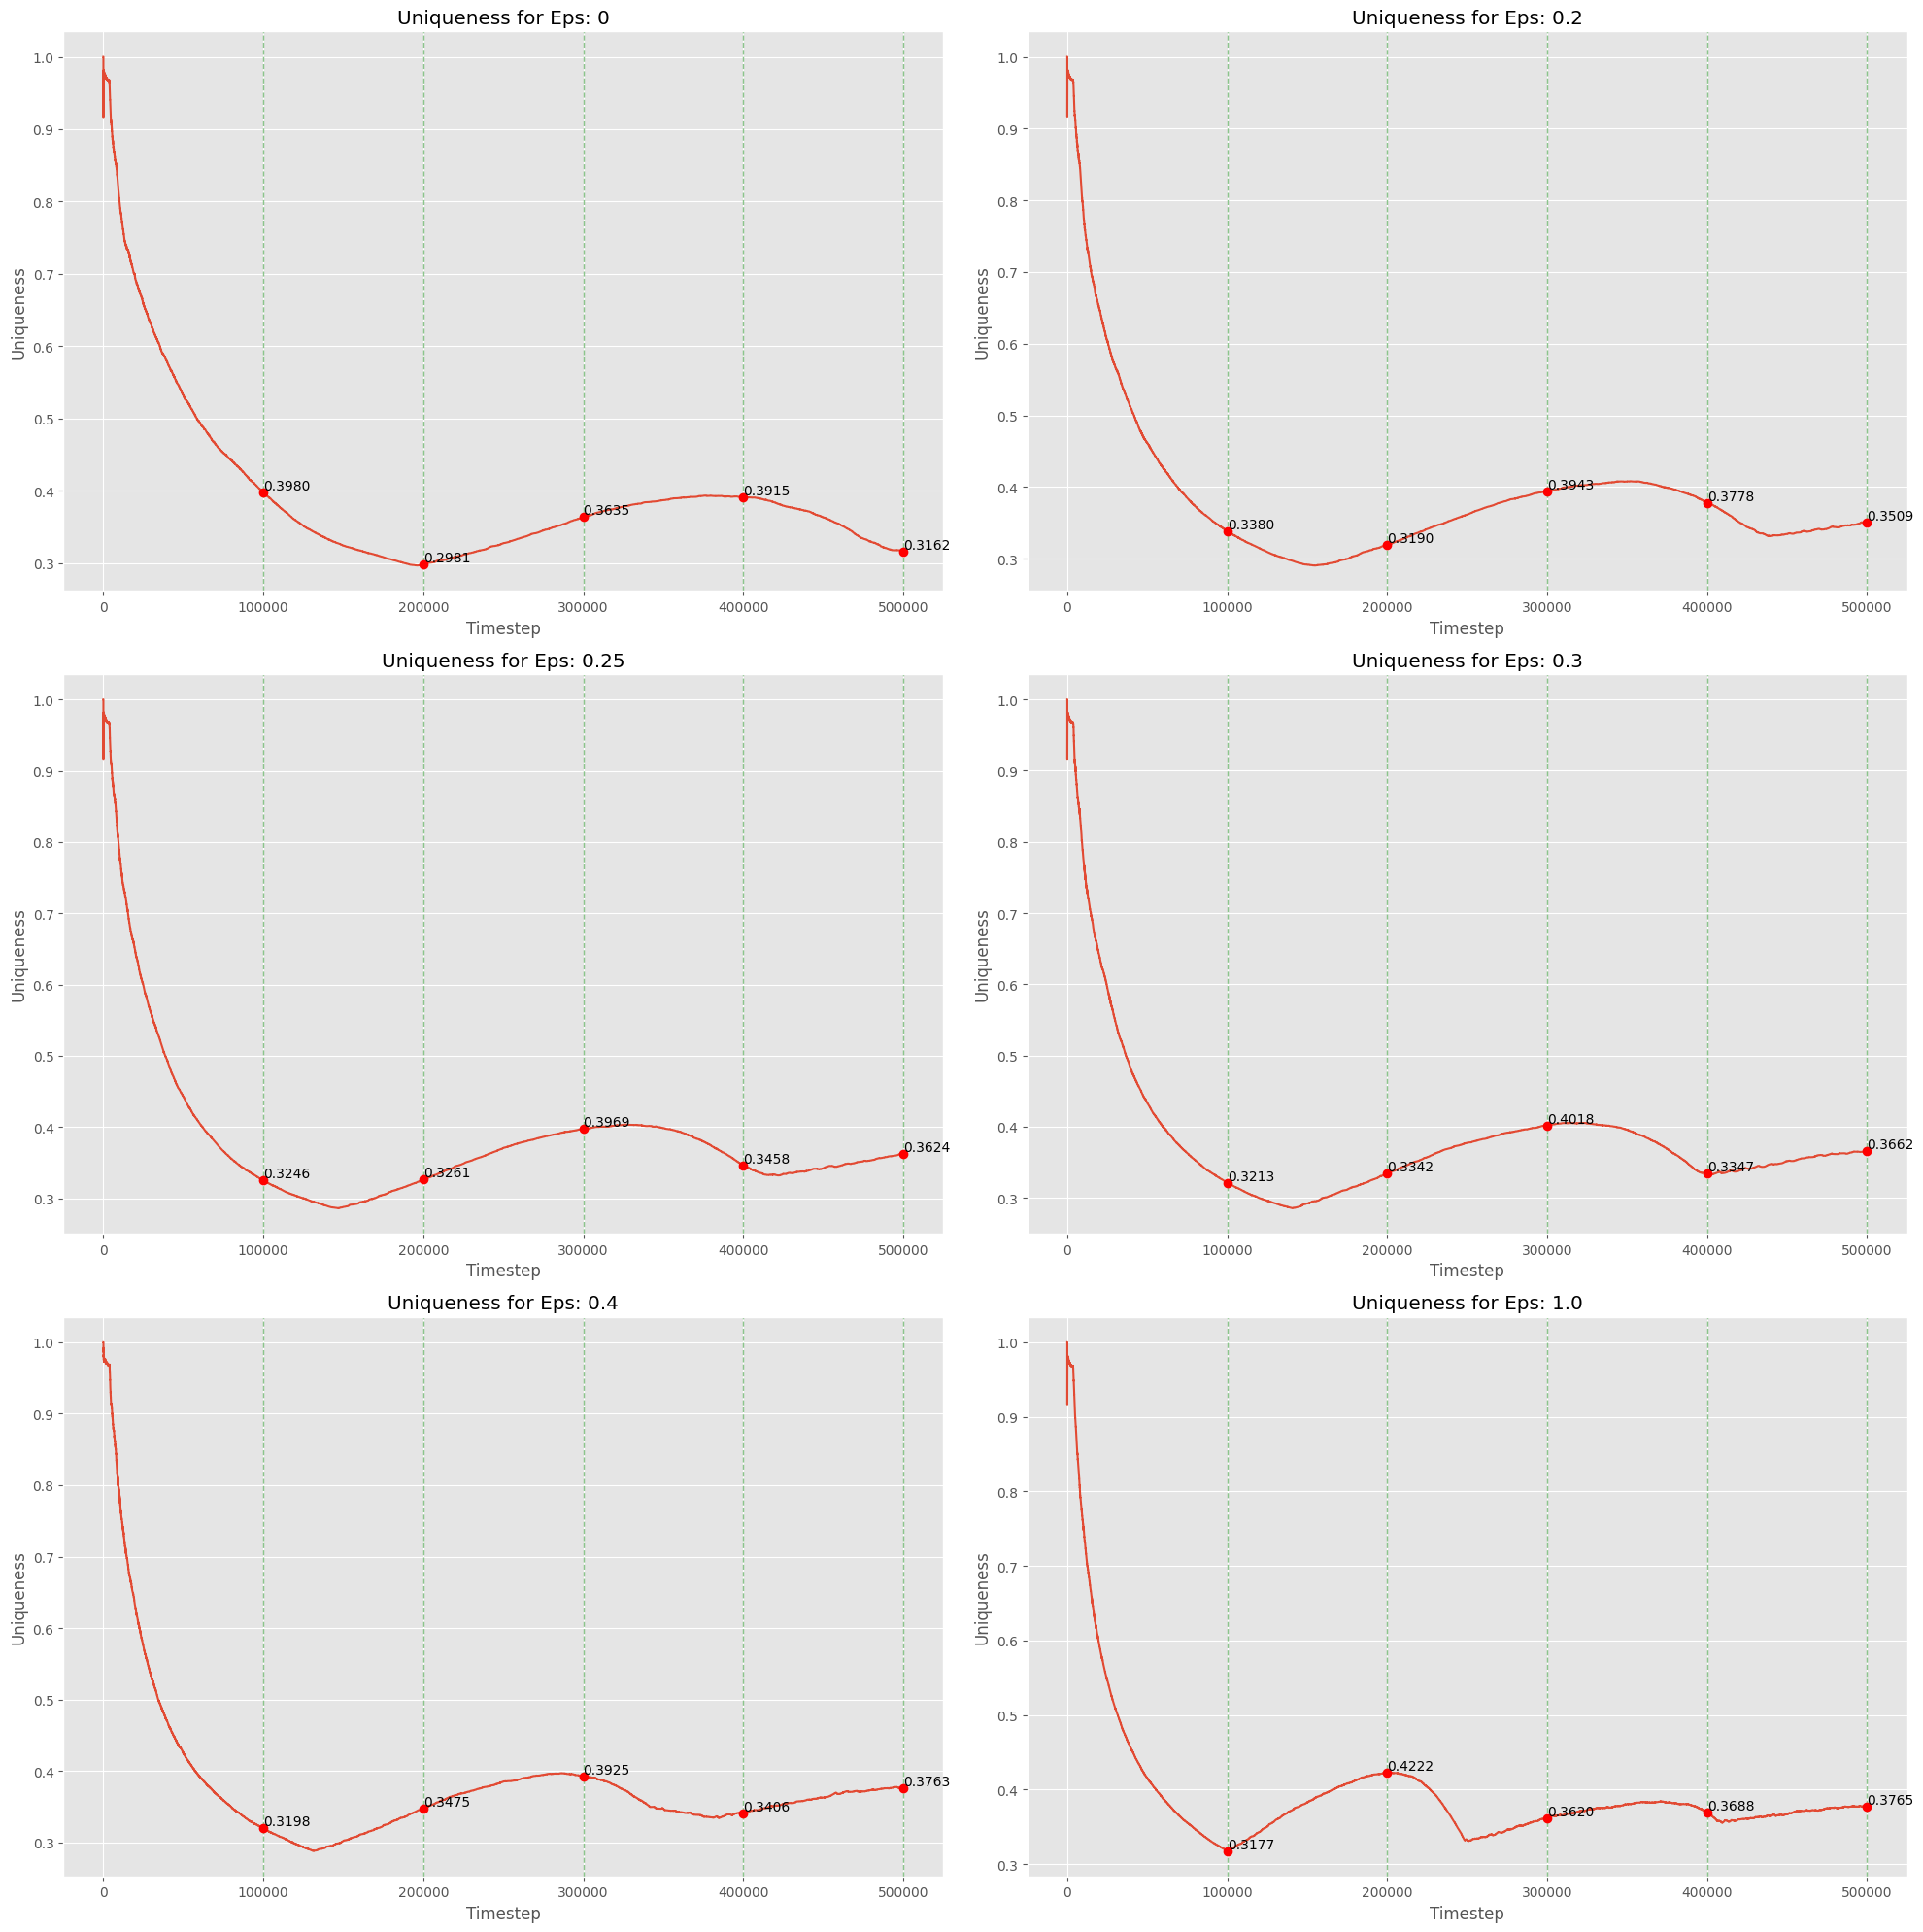

In [51]:
plot_uniqueness(([0, 0.2, 0.25, 0.3, 0.4, 1.0],))

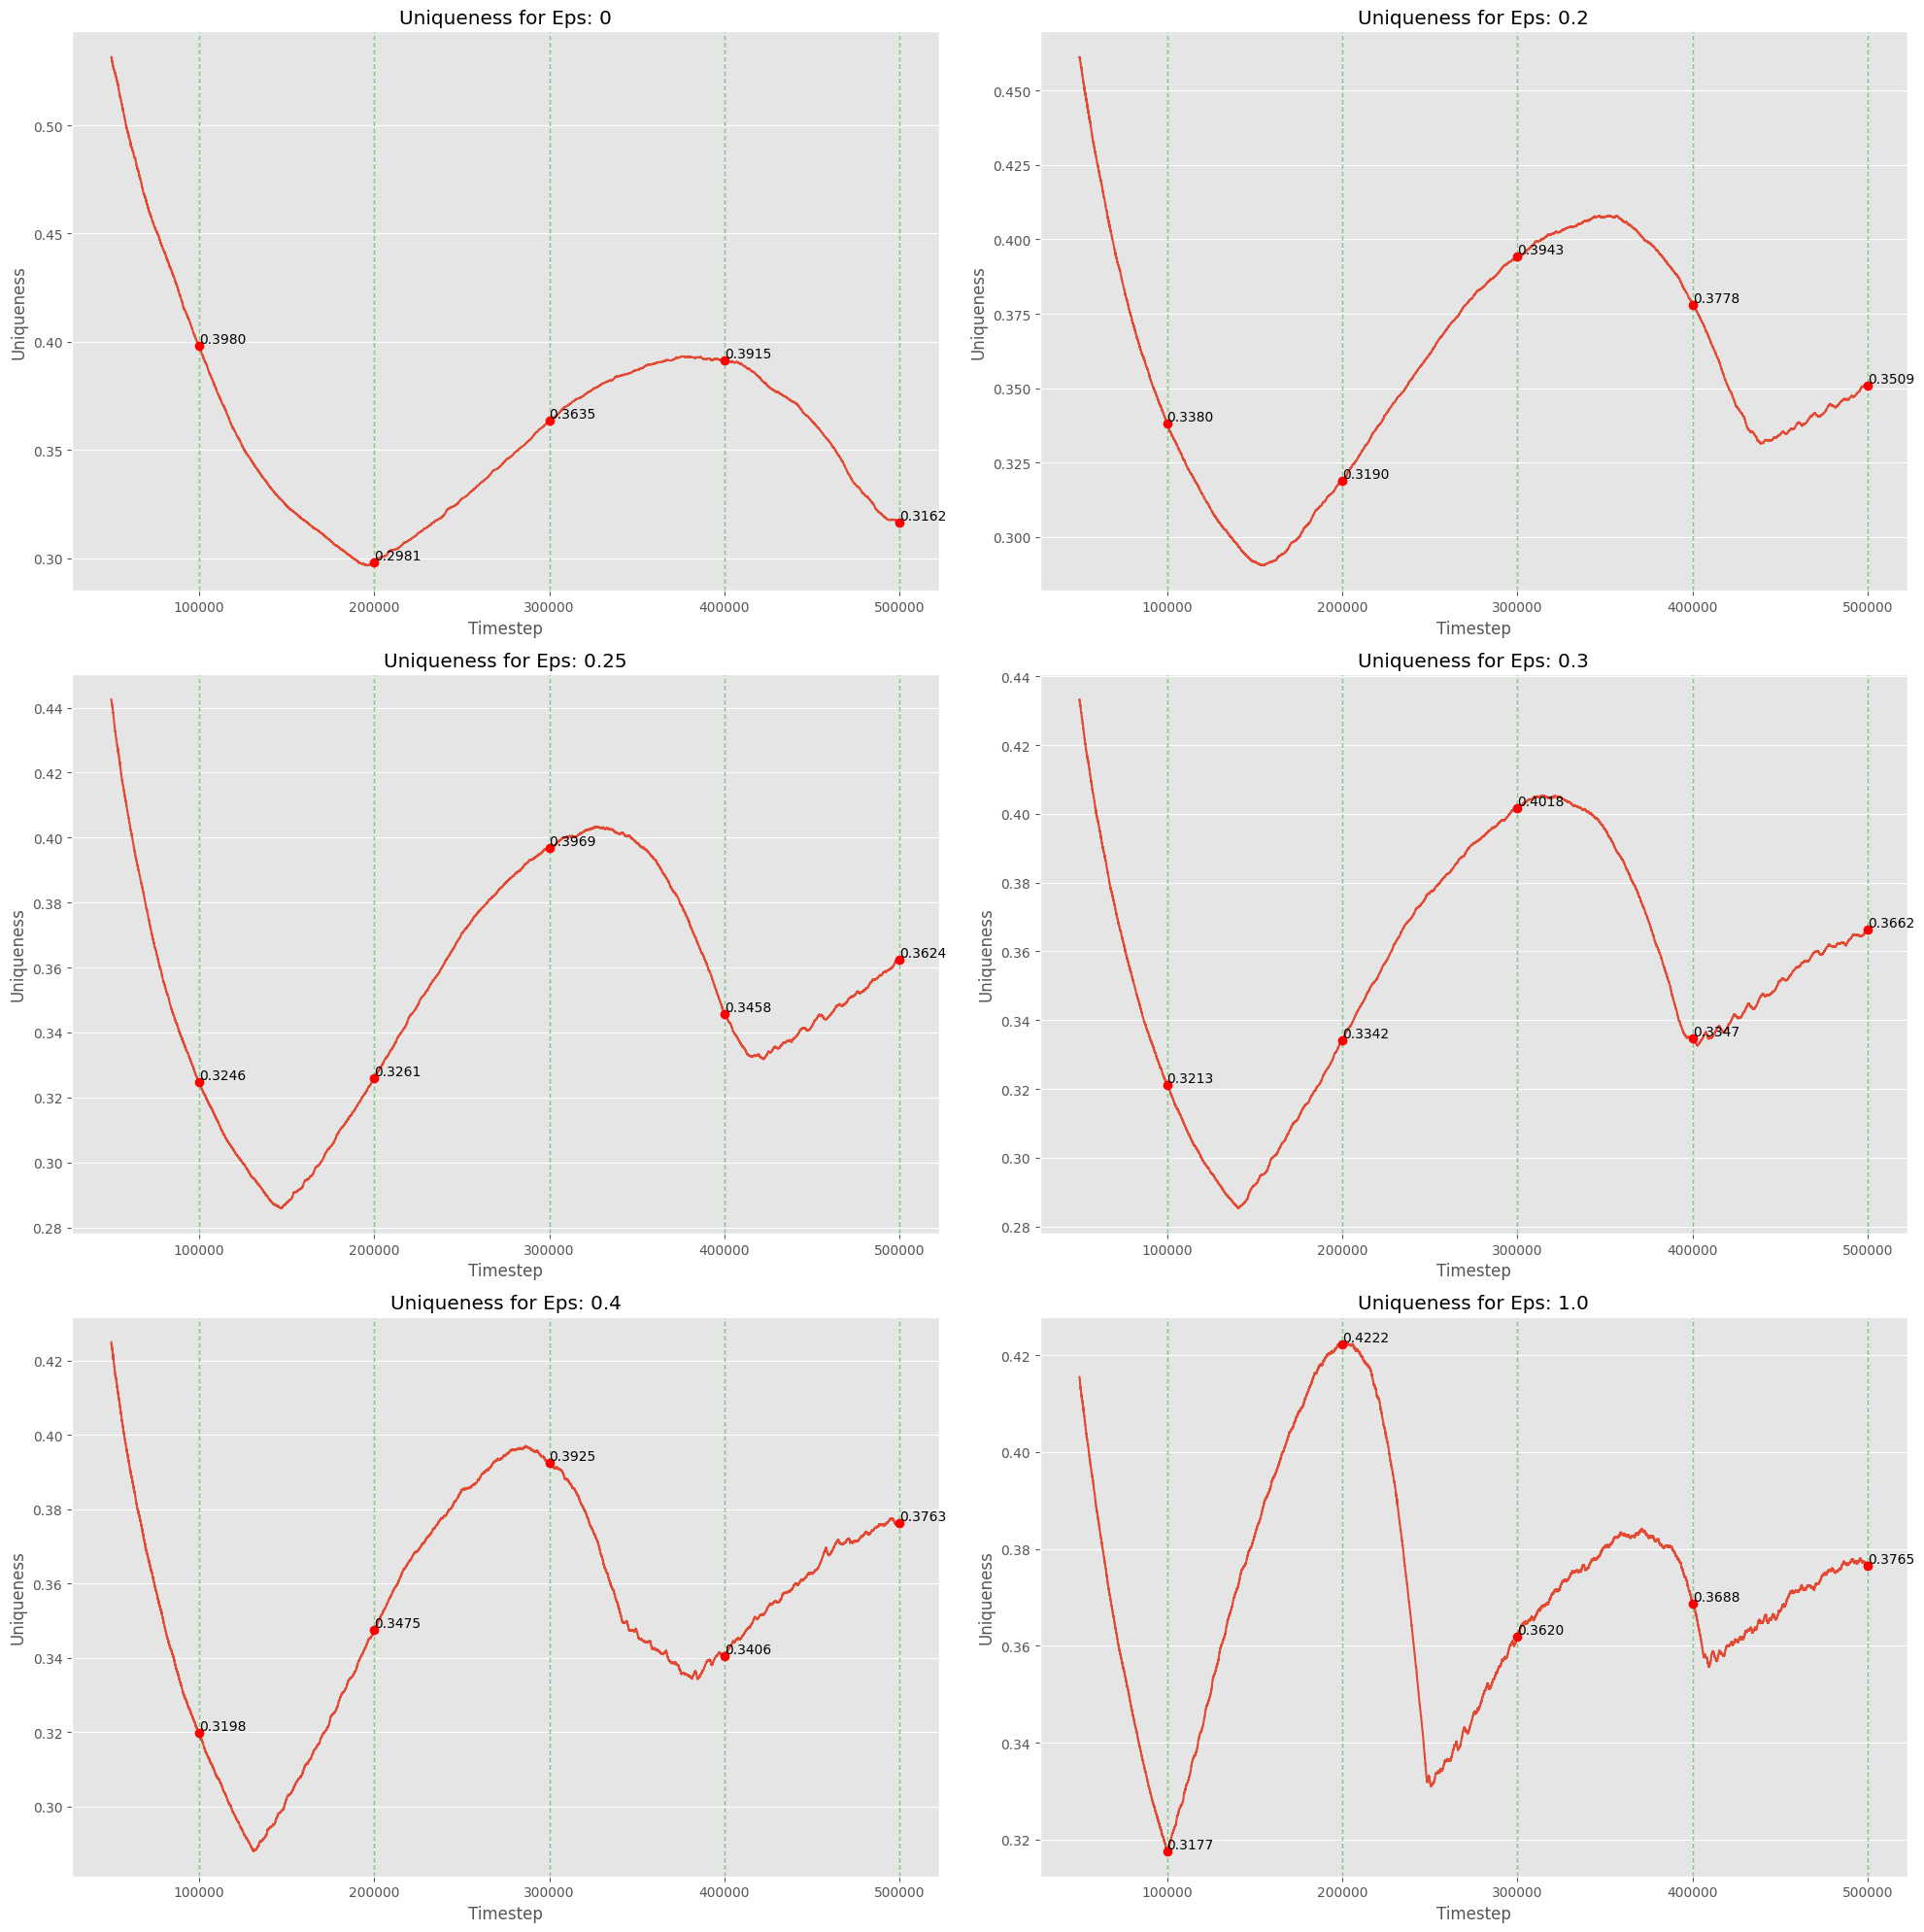

In [52]:
plot_uniqueness(([0, 0.2, 0.25, 0.3, 0.4, 1.0],), (50000, 500000))

In [2]:
with open(f'results/dqn_evals/eval_dqn_mlp_norm_kaiming_4M_seed_2.pl', 'rb') as file:
    temp = dill.load(file)

In [4]:
temp.keys()

dict_keys(['train/ep_rew_mean', 'train/ep_len_mean', 'train/total_timesteps', 'eval/mean_reward', 'eval/mean_ep_length', 'time/total_timesteps'])

In [2]:
import os

# def make_table_dqn(hyperparameters):
#     Config = make_dataclass("Config", [
#         ("name", str),
#         ("train_score", float),
#         ("eval_score", float),
#         ("UB", float),
#         ("LB", float),
#     ])
    
#     data_objs = []
#     for arch in hyperparameters[0]:
#         for act in hyperparameters[1]:
#             for dual in hyperparameters[2]:
#                 for norm in hyperparameters[3]:
#                     for init in hyperparameters[4]:
#                         seed_comb = []
#                         skip = False
#                         for seed in [0, 1, 2, 3]:
#                             file_name = f'eval_dqn{arch}{act}{dual}{norm}{init}_6M_seed_{seed}.pl'
#                             try:
#                                 with open(f'results/dqn_evals/{file_name}', 'rb') as file:
#                                     temp = dill.load(file)
#                                     seed_comb.append(temp)
#                             except FileNotFoundError:
#                                 skip = True
#                                 continue
                        
#                         if skip: 
#                             continue
                        
#                         name = file_name[9:-13]
#                         final_train = np.mean([res['train/ep_rew_mean'][-1] for res in seed_comb])
#                         final_evals = [res['eval/mean_reward'][-1] for res in seed_comb]
#                         final_eval = np.mean(final_evals)
#                         ub = np.percentile(final_evals, q=95) 
#                         lb = np.percentile(final_evals, q=5)    

#                         data_objs.append(
#                             Config(name, final_train, final_eval, ub, lb)
#                         ) 
            
#     return pd.DataFrame(data_objs)

def make_table_dqn(hyperparameters):
    Config = make_dataclass("Config", [
        ("name", str),
        ("train_score", float),
        ("train_max", float),   # New
        ("eval_score", float),
        ("eval_max", float),    # New
        ("UB", float),
        ("LB", float),
    ])
    
    data_objs = []
    
    cnns = hyperparameters[0]
    acts = hyperparameters[1]
    duals = hyperparameters[2]
    norms = hyperparameters[3]
    inits = hyperparameters[4]
    mods = hyperparameters[5]

    for init in inits:
        for use_cnn in cnns:
            for use_act in acts:
                for use_dual in duals:
                    for use_norm in norms:
                        for mod in mods: 

                            seed_comb = []
                            skip = False
                            
                            name_cnn = "_cnn" if use_cnn else "_mlp"
                            name_norm = "_norm" if use_norm else ""
                            name_act = "_act" if use_act else ""
                            name_dual = "_dual" if use_dual else ""
                            name_mod = "_" + mod
                            
                            name_init = "_" + init
                            time_name = "6M" 
                            
                            group_name = f"eval_dqn{name_cnn}{name_act}{name_dual}{name_norm}{name_init}{name_mod}_{time_name}"

                            for seed in [0, 1, 2, 3]:
                                file_path = f'results/dqn_evals/{group_name}_seed_{seed}.pl'
                                if not os.path.exists(file_path):
                                    skip = True
                                    break
                                
                                try:
                                    with open(file_path, 'rb') as file:
                                        seed_comb.append(dill.load(file))
                                except Exception:
                                    skip = True
                                    break
                            
                            if skip or not seed_comb:
                                continue

                            final_train_scores = [res['train/ep_rew_mean'][-1] for res in seed_comb]
                            final_eval_scores = [res['eval/mean_reward'][-1] for res in seed_comb]

                            max_train_scores = [np.max(res['train/ep_rew_mean']) for res in seed_comb]
                            max_eval_scores = [np.max(res['eval/mean_reward']) for res in seed_comb]
                            
                            data_objs.append(Config(
                                name=group_name[9:-3],
                                train_score=float(np.mean(final_train_scores)),
                                train_max=float(np.mean(max_train_scores)),
                                eval_score=float(np.mean(final_eval_scores)),
                                eval_max=float(np.mean(max_eval_scores)),
                                UB=float(np.percentile(final_eval_scores, 95)),
                                LB=float(np.percentile(final_eval_scores, 5))
                            ))
            
    return pd.DataFrame(data_objs)

In [18]:
make_table_dqn(
    [('_cnn', '_mlp'), ('', '_act'), ('', '_dual'), 
     ('', '_norm'), ('_kaiming', '_orthogonal')]
)

,name,train_score,eval_score,UB,LB
0,cnn_kaiming,0.845740,0.859897,0.867776,0.854241
1,cnn_orthogonal,0.613703,0.571765,0.835674,0.318367
2,cnn_norm_kaiming,0.838600,0.859915,0.863556,0.854605
3,cnn_norm_orthogonal,0.839650,0.868075,0.871309,0.863088
4,cnn_act_kaiming,0.007967,0.000000,0.000000,0.000000
5,cnn_act_orthogonal,0.283360,0.284868,0.769144,0.000000
6,cnn_act_norm_kaiming,0.832330,0.853505,0.860410,0.844035
7,cnn_act_norm_orthogonal,0.841780,0.862555,0.864010,0.860081
8,mlp_kaiming,0.246950,0.037617,0.070928,0.007271
9,mlp_orthogonal,0.842287,0.800610,0.827994,0.776901


In [ ]:
# multiplying the different versions

make_table_dqn(
    [('_cnn', '_mlp'), ('', '_act'), ('', '_dual'), 
     ('', '_norm'), ('_kaiming', '_orthogonal')]
)

,name,train_score,eval_score,UB,LB
0,cnn_kaiming,0.835525,0.856189,0.860333,0.849446
1,cnn_orthogonal,0.265110,0.219910,0.733286,0.000723
2,cnn_norm_kaiming,0.845785,0.856585,0.862692,0.852998
3,cnn_norm_orthogonal,0.844503,0.857811,0.863551,0.852182
4,cnn_act_kaiming,0.020213,0.006511,0.018953,0.000000
5,cnn_act_orthogonal,0.017155,0.000913,0.003102,0.000000
6,cnn_act_norm_kaiming,0.023260,0.013545,0.021563,0.005026
7,cnn_act_norm_orthogonal,0.031650,0.022179,0.032684,0.012868
8,mlp_kaiming,0.350463,0.080807,0.123403,0.026182
9,mlp_orthogonal,0.843715,0.839330,0.856968,0.821657


In [4]:
# embed size 32

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

hyperparameters = [
    [True, False],                  
    [True],                         
    [True, False],                  
    [True, False],                  
    ["orthogonal", "kaiming"],
    ["one_hot"]       
]  

df_results = make_table_dqn(hyperparameters)
df_results.sort_values(by="eval_score", ascending=False)

,name,train_score,train_max,eval_score,eval_max,UB,LB
6,cnn_act_norm_kaiming_one_hot,0.845065,0.870962,0.864302,0.869196,0.870751,0.859303
3,mlp_act_dual_orthogonal_one_hot,0.845020,0.872065,0.860541,0.865899,0.867034,0.853476
2,mlp_act_dual_norm_orthogonal_one_hot,0.840565,0.873415,0.860275,0.865630,0.868278,0.852398
8,mlp_act_dual_norm_kaiming_one_hot,0.842050,0.874450,0.858284,0.867070,0.862773,0.854535
9,mlp_act_dual_kaiming_one_hot,0.839125,0.871007,0.858033,0.862906,0.860429,0.855846
4,mlp_act_norm_orthogonal_one_hot,0.843850,0.869792,0.855749,0.863470,0.864134,0.838948
10,mlp_act_norm_kaiming_one_hot,0.829987,0.871412,0.854378,0.864460,0.858519,0.851310
11,mlp_act_kaiming_one_hot,0.837502,0.868780,0.852355,0.865934,0.868337,0.830805
5,mlp_act_orthogonal_one_hot,0.842207,0.870130,0.850137,0.863185,0.860922,0.841118
0,cnn_act_norm_orthogonal_one_hot,0.640305,0.678802,0.647998,0.656373,0.865342,0.132961


In [4]:
def make_table_uvu(names, hyperparameters):
    Config = make_dataclass("Config", [
        ("name", str),
        ("alpha", float),
        ("uniqueness_end", float),
        ("uniqueness10", float),
        ("uniqueness50", float),
        ("uniqueness90", float),
        ("size_end", float),
        ("filename", str)
    ])
    
    data_objs = []
    for name in names:
        for alpha in hyperparameters[0]:
            seed_comb = []
            for seed in [0]:
                cleaned_alpha = str(alpha).replace('.', '')
                file_name = f'uvu_{name}__alpha{cleaned_alpha}_seed_{seed}_300000.pl'
                with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                    temp = dill.load(file)
                    seed_comb.append(temp)
            
            length = len(seed_comb[0]['uniqueness'])
            idx_10 = int(0.10 * (length - 1))
            idx_50 = int(0.50 * (length - 1))
            idx_90 = int(0.90 * (length - 1))

            end_uniqueness = np.mean([res['uniqueness'][-1] for res in seed_comb])
            unique_10 = np.mean([res['uniqueness'][idx_10] for res in seed_comb])
            unique_50 = np.mean([res['uniqueness'][idx_50] for res in seed_comb])
            unique_90 = np.mean([res['uniqueness'][idx_90] for res in seed_comb])    
            size_end = np.mean([res['buffer'].size for res in seed_comb])

            data_objs.append(
                Config(name, alpha, end_uniqueness, unique_10, unique_50, unique_90, size_end, file_name)
            ) 
            
    return pd.DataFrame(data_objs)

In [5]:
pd.set_option('display.max_colwidth', None)

make_table_uvu(['cnn_act_norm_orthogonal', 'mlp_act_dual_norm_kaiming'], [(0.0, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0)])

,name,alpha,uniqueness_end,uniqueness10,uniqueness50,uniqueness90,size_end,filename
0,cnn_act_norm_orthogonal,0.00,0.216370,0.557318,0.176620,0.215520,100000.0,uvu_cnn_act_norm_orthogonal__alpha00_seed_0_300000.pl
1,cnn_act_norm_orthogonal,0.20,0.218720,0.680076,0.191544,0.212920,100000.0,uvu_cnn_act_norm_orthogonal__alpha02_seed_0_300000.pl
2,cnn_act_norm_orthogonal,0.50,0.274110,0.694572,0.241071,0.259390,100000.0,uvu_cnn_act_norm_orthogonal__alpha05_seed_0_300000.pl
3,cnn_act_norm_orthogonal,0.75,0.267550,0.804127,0.283768,0.251560,100000.0,uvu_cnn_act_norm_orthogonal__alpha075_seed_0_300000.pl
4,cnn_act_norm_orthogonal,1.00,0.271990,0.850654,0.318401,0.258750,100000.0,uvu_cnn_act_norm_orthogonal__alpha10_seed_0_300000.pl
5,cnn_act_norm_orthogonal,1.50,0.289463,0.879204,0.432186,0.307528,89400.0,uvu_cnn_act_norm_orthogonal__alpha15_seed_0_300000.pl
6,cnn_act_norm_orthogonal,2.00,0.398342,0.931632,0.577073,0.419120,46676.0,uvu_cnn_act_norm_orthogonal__alpha20_seed_0_300000.pl
7,cnn_act_norm_orthogonal,2.50,0.547275,0.946464,0.738260,0.574921,23374.0,uvu_cnn_act_norm_orthogonal__alpha25_seed_0_300000.pl
8,cnn_act_norm_orthogonal,3.00,0.705893,0.951499,0.820236,0.723453,11574.0,uvu_cnn_act_norm_orthogonal__alpha30_seed_0_300000.pl
9,mlp_act_dual_norm_kaiming,0.00,0.253980,0.522794,0.204012,0.244460,100000.0,uvu_mlp_act_dual_norm_kaiming__alpha00_seed_0_300000.pl


In [13]:
def make_table_opt(hyperparameters):
    Config = make_dataclass("Config", [
        ("alpha", float),
        ("uniqueness_end", float),
        ("uniqueness10", float),
        ("uniqueness50", float),
        ("uniqueness90", float),
        ("size_end", float),
        ("filename", str)
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        clean_alpha = str(alpha).replace(".", "")
        seed_comb = []
        for seed in [0, 1, 2, 3]:
            file_name = f'opt_count_alpha{clean_alpha}_seed_{seed}_300000.pl'
            with open(f'results/dqn_exps/{file_name}', 'rb') as file:
                temp = dill.load(file)
                seed_comb.append(temp)

        length = len(seed_comb[0]['uniqueness'])
        idx_10 = int(0.10 * (length - 1))
        idx_50 = int(0.50 * (length - 1))
        idx_90 = int(0.90 * (length - 1))

        end_uniqueness = np.mean([res['uniqueness'][-1] for res in seed_comb])
        unique_10 = np.mean([res['uniqueness'][idx_10] for res in seed_comb])
        unique_50 = np.mean([res['uniqueness'][idx_50] for res in seed_comb])
        unique_90 = np.mean([res['uniqueness'][idx_90] for res in seed_comb])    
        size_end = np.mean([res['buffer'].size for res in seed_comb])

        data_objs.append(
            Config(alpha, end_uniqueness, unique_10, unique_50, unique_90, size_end, file_name)
        )
            
    return pd.DataFrame(data_objs)


In [14]:
make_table_opt([(0.2, 0.5, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 3.5)])

,alpha,uniqueness_end,uniqueness10,uniqueness50,uniqueness90,size_end,filename
0,0.2,0.277595,0.461849,0.227260,0.280365,100000.00,opt_count_alpha02_seed_3_300000.pl
1,0.5,0.338478,0.488534,0.283463,0.340295,100000.00,opt_count_alpha05_seed_3_300000.pl
2,1.0,0.377290,0.569660,0.315911,0.369485,100000.00,opt_count_alpha10_seed_3_300000.pl
3,1.2,0.396890,0.635632,0.332778,0.383380,100000.00,opt_count_alpha12_seed_3_300000.pl
4,1.5,0.407055,0.755458,0.356363,0.389920,100000.00,opt_count_alpha15_seed_3_300000.pl
5,2.0,0.397820,0.955812,0.461685,0.378275,100000.00,opt_count_alpha20_seed_3_300000.pl
6,2.5,0.959987,0.974666,0.956275,0.958741,1844.25,opt_count_alpha25_seed_3_300000.pl
7,3.0,0.974747,0.974747,0.974747,0.974747,26.75,opt_count_alpha30_seed_3_300000.pl
8,3.5,0.974747,0.974747,0.974747,0.974747,18.00,opt_count_alpha35_seed_3_300000.pl


In [12]:
def make_table_uvu(hyperparameters, model_name: str = 'uvu'):
    Config = make_dataclass("Config", [
        ("name", str),
        ("gradsteps", float),
        ("uniqueness_end", float),
        ("uniqueness10", float),
        ("uniqueness50", float),
        ("uniqueness90", float),
        ("size_end", float),
        ("filename", str)
    ])
    
    data_objs = []
    
    cnns = hyperparameters[0]
    acts = hyperparameters[1]
    duals = hyperparameters[2]
    norms = hyperparameters[3]
    inits = hyperparameters[4]
    mods = hyperparameters[5]
    grad_steps = hyperparameters[6]

    for init in inits:
        for use_cnn in cnns:
            for use_act in acts:
                for use_dual in duals:
                    for use_norm in norms:
                            for mod in mods:
                                for grad in grad_steps:

                                    seed_comb = []
                                    skip = False
                                    
                                    name_cnn = "_cnn" if use_cnn else "_mlp"
                                    name_norm = "_norm" if use_norm else ""
                                    name_act = "_act" if use_act else ""
                                    name_dual = "_dual" if use_dual else ""
                                    
                                    name_init = "_" + init
                                    time_name = "300000" 
                                    
                                    group_name = f"{model_name}{name_cnn}{name_act}{name_dual}{name_norm}{name_init}_alpha05_{mod}_grad{grad}"
                                    print(group_name)

                                    for seed in [0, 1, 2]:
                                        file_path = f'{group_name}_seed_{seed}_{time_name}.pl'
                                        try:
                                            with open(f'results/dqn_exps/{file_path}', 'rb') as file:
                                                seed_comb.append(dill.load(file))
                                        except Exception:
                                            skip = True
                                            break
                                    
                                    if skip or not seed_comb:
                                        continue
                                    
                                    name = group_name[4:-15]
                                    length = len(seed_comb[0]['uniqueness'])
                                    idx_10 = int(0.10 * (length - 1))
                                    idx_50 = int(0.50 * (length - 1))
                                    idx_90 = int(0.90 * (length - 1))

                                    end_uniqueness = np.mean([res['uniqueness'][-1] for res in seed_comb])
                                    unique_10 = np.mean([res['uniqueness'][idx_10] for res in seed_comb])
                                    unique_50 = np.mean([res['uniqueness'][idx_50] for res in seed_comb])
                                    unique_90 = np.mean([res['uniqueness'][idx_90] for res in seed_comb])    
                                    if model_name == "uuv":
                                        size_end = np.mean([res['buffer'].size for res in seed_comb])
                                    else:
                                        size_end = np.mean([res['counter_moving'].size for res in seed_comb])

                                    data_objs.append(
                                        Config(name, grad, end_uniqueness, unique_10, unique_50, unique_90, size_end, file_path)
                                    )
                
    return pd.DataFrame(data_objs)

In [16]:
# embed size 32

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

hyperparameters = [
    [True, False],                  
    [True],                         
    [True, False],                  
    [True, False],                  
    ["orthogonal", "kaiming"],
    ["one_hot"],
    [5, 10, 15]      
]  

df_results = make_table_uvu(hyperparameters)
df_results

,name,gradsteps,uniqueness_end,uniqueness10,uniqueness50,uniqueness90,size_end,filename
0,mlp_act_dual_norm_orthogona,5,0.249100,0.480435,0.192180,0.242953,100000.0,uvu_mlp_act_dual_norm_orthogonal_alpha05_grad5_seed_2_300000.pl
1,mlp_act_dual_norm_orthogonal,10,0.261093,0.474629,0.199563,0.255470,100000.0,uvu_mlp_act_dual_norm_orthogonal_alpha05_grad10_seed_2_300000.pl
2,mlp_act_dual_norm_orthogonal,15,0.268140,0.477603,0.199510,0.258333,100000.0,uvu_mlp_act_dual_norm_orthogonal_alpha05_grad15_seed_2_300000.pl
3,mlp_act_dual_orthogona,5,0.264017,0.507550,0.201673,0.253660,100000.0,uvu_mlp_act_dual_orthogonal_alpha05_grad5_seed_2_300000.pl
4,mlp_act_dual_orthogonal,10,0.257537,0.465941,0.192043,0.253147,100000.0,uvu_mlp_act_dual_orthogonal_alpha05_grad10_seed_2_300000.pl
5,mlp_act_dual_orthogonal,15,0.263917,0.459236,0.191950,0.254023,100000.0,uvu_mlp_act_dual_orthogonal_alpha05_grad15_seed_2_300000.pl
6,cnn_act_norm_kaimin,5,0.374883,0.584480,0.329333,0.363070,100000.0,uvu_cnn_act_norm_kaiming_alpha05_grad5_seed_2_300000.pl
7,cnn_act_norm_kaiming,10,0.387333,0.589027,0.340922,0.377327,100000.0,uvu_cnn_act_norm_kaiming_alpha05_grad10_seed_2_300000.pl
8,cnn_act_norm_kaiming,15,0.403710,0.584025,0.341790,0.392027,100000.0,uvu_cnn_act_norm_kaiming_alpha05_grad15_seed_2_300000.pl


In [13]:
# dqn

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

hyperparameters = [
    [True],                  
    [True],                         
    [False],                  
    [True],                  
    ["kaiming"],
    ["one_hot"],
    [15, 20]      
]  

df_results = make_table_uvu(hyperparameters, 'dqn')
df_results

dqn_cnn_act_norm_kaiming_alpha05_one_hot_grad15
dqn_cnn_act_norm_kaiming_alpha05_one_hot_grad20


,name,gradsteps,uniqueness_end,uniqueness10,uniqueness50,uniqueness90,size_end,filename
0,cnn_act_norm_kaiming_alpha05,15,0.088593,0.341965,0.114487,0.125663,100000.0,dqn_cnn_act_norm_kaiming_alpha05_one_hot_grad15_seed_2_300000.pl
1,cnn_act_norm_kaiming_alpha05,20,0.089913,0.327557,0.112107,0.126893,100000.0,dqn_cnn_act_norm_kaiming_alpha05_one_hot_grad20_seed_2_300000.pl
